<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Андрей! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Привет, Павел!</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Проект: прогноз вероятности клика по рекламному объявлению (CTR)

## https://github.com/2Myaka2/Logistic_reg
Запускать лучше из репозитория.

#### Описание проекта

В этом проекте решается задача бинарной классификации: необходимо предсказать вероятность клика пользователя по рекламному баннеру.

Модель используется в рекламной платформе для принятия решений в режиме реального времени. Предсказанная вероятность клика влияет на расчёт ожидаемого дохода в аукционе:

Поэтому важно не только хорошо разделять классы, но и получать качественно откалиброванные вероятности.

#### Бизнес-ценность

Точная оценка CTR позволяет:
- корректно ранжировать объявления в рекламном аукционе;
- повышать ожидаемую выручку платформы;
- лучше понимать, какие факторы влияют на вероятность клика;
- использовать модель в продакшене без расхождений между обучением и применением.

#### Цель проекта

Построить интерпретируемую модель предсказания клика, которая:
- показывает хорошее качество на задаче дисбалансной бинарной классификации;
- выдаёт корректные вероятности;
- проходит калибровку;
- оформлена в виде воспроизводимого пайплайна.

#### Используемые данные

В датасете содержатся:
- идентификаторы показов и временные метки;
- характеристики сайта;
- характеристики рекламируемого приложения;
- данные об устройстве пользователя и соединении;
- параметры баннера и аукциона;
- машинно-сгенерированные признаки;
- целевая переменная `click`.

#### Ключевые метрики

Для оценки качества модели используются:
- **PR-AUC** — основная метрика для задачи с дисбалансом классов;
- **Log Loss** — оценка качества вероятностного прогноза;
- **Brier Score** — оценка калибровки вероятностей.

#### Требования к итоговому решению

Итоговое решение должно:
- быть воспроизводимым (`random_state` фиксирован);
- включать предобработку в составе пайплайна;
- содержать калибровку модели;
- быть готовым к сохранению и использованию в продакшене.

#### План работы

1. Подготовка среды и загрузка данных  
2. Исследовательский анализ данных  
3. Разделение данных на выборки  
4. Предобработка и построение пайплайнов  
5. Отбор признаков  
6. Обучение базовой модели  
7. Подбор гиперпараметров  
8. Обучение финальной модели  
9. Калибровка вероятностей  
10. Оценка качества калибровки  
11. Финальные выводы  
12. Сохранение модели

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [55]:
%%writefile requirements.txt
# Tested with Python 3.14.3
numpy==2.3.5
pandas==2.2.3
scipy==1.17.0
scikit-learn==1.8.0
matplotlib==3.10.8
seaborn==0.13.2
joblib==1.5.3
ipykernel==6.29.5

Overwriting requirements.txt


In [56]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, RFE, SelectKBest, r_regression
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

import joblib
from pathlib import Path

RANDOM_STATE = 42

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color="red">Все зависимомсти нужно явно установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.</span>

</span><br><span style="color: purple; font-weight: bold">Поправил</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> \
<span style="color: blue"> sklearn: 1.8.0 требует Python >3.11 и здесь работать не будет.</span>

</span><br><span style="color: purple; font-weight: bold">Я работаю локально с VSC (сдаю так уже несколько проектов). Верно ли я понимаю, что этот комментарий просто предупреждение и мне не нужно переписать код под более старую версию Python?</span>

In [57]:
! python --version

Python 3.14.3


In [58]:
local_path = 'ds_s16_ad_click_dataset.csv'
server_path = '/datasets/ds_s16_ad_click_dataset.csv'
url_path = 'https://code.s3.yandex.net/datasets/ds_s16_ad_click_dataset.csv'

if os.path.exists(local_path):
    data_path = local_path
elif os.path.exists(server_path):
    data_path = server_path
else:
    data_path = url_path

df = pd.read_csv(data_path)

print(f'Данные успешно загружены из: {data_path}')

Данные успешно загружены из: ds_s16_ad_click_dataset.csv


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Ошибка загрузки данных.\
Данные должны загружаться у тех кому ты демонстрируешь свою работу.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>При считывании данных из файла здорово перестраховывать себя от ошибок, связанных, например, с неверным указанием пути к файлу. А иногда бывает, что работаешь с файлом локально, выгружаешь его на сервер, ожидая, что он будет принимать данные, которые лежат на том же сервере, а код падает с ошибкой, потому что путь к файлу не поменялся с локального на серверный.
    
Для этого, например, можно использовать конструкцию `try-except`: сначала пробуешь локальный путь, при возникновении ошибки используется серверный путь (подробнее можешь почитать тут: https://pythonworld.ru/tipy-dannyx-v-python/isklyucheniya-v-python-konstrukciya-try-except-dlya-obrabotki-isklyuchenij.html).
    
Но еще лучше использовать библиотеку `os` - её использование позволит тебе проверять существование указанных директорий (что может быть актуально при одновременной работа на локальном и сетевом окружении) и загружать данные из существующей директории, избегая ошибок. Как пример:
```python    
    import os

    pth1 = '/folder_1/data.csv'
    pth2 = '/folder_2/data.csv'
    
    if os.path.exists(pth1):
        query_1 = pd.read_csv(pth1)
    elif os.path.exists(pth2):
        query_1 = pd.read_csv(pth2)
    else:
        print('Something is wrong')
```
Так же, данные Практикума можно загружать напрямую с базы:\
`data = pd.read_csv('https://code.s3.yandex.net/datasets/имя_файла.csv')`</font>

</span><br><span style="color: purple; font-weight: bold">Исправил и перестраховался)</span>

In [59]:
df.info()

display(df.head())

print('\nКоличество дубликатов:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909



Количество дубликатов: 0


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Первичный осмотр проведен.</font>

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

In [60]:
# 2.0 Подготовка данных для EDA
 
df_eda = df.copy()

# Распаковываем признак hour
hour_dt = pd.to_datetime(
    df_eda["hour"].astype(str).str.zfill(8),
    format="%y%m%d%H",
    errors="coerce"
)

df_eda["hour_of_day"] = hour_dt.dt.hour
df_eda["day_of_week_num"] = hour_dt.dt.dayofweek
df_eda["day_of_week"] = hour_dt.dt.day_name()
df_eda["is_weekend"] = (df_eda["day_of_week_num"] >= 5).astype(int)

print("Проверка преобразования hour:")
display(
    df_eda[["hour", "hour_of_day", "day_of_week_num", "day_of_week", "is_weekend"]].head()
)

Проверка преобразования hour:


,hour,hour_of_day,day_of_week_num,day_of_week,is_weekend
0,14102100,0,1,Tuesday,0
1,14102100,0,1,Tuesday,0
2,14102100,0,1,Tuesday,0
3,14102100,0,1,Tuesday,0
4,14102100,0,1,Tuesday,0


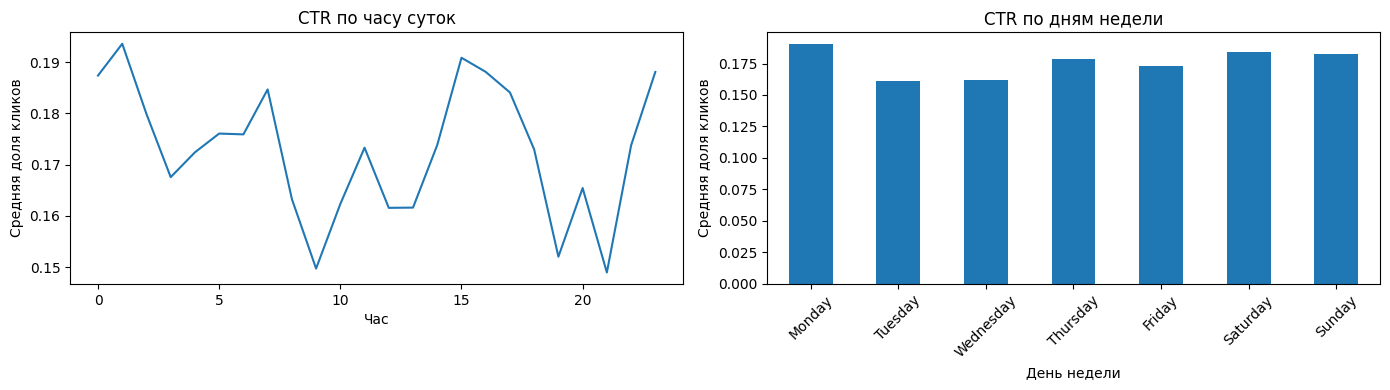

In [61]:
# Проверим, полезна ли распаковка hour

hour_ctr = df_eda.groupby("hour_of_day")["click"].mean()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_ctr = (
    df_eda.groupby("day_of_week")["click"].mean()
    .reindex(dow_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_ctr.plot(ax=axes[0])
axes[0].set_title("CTR по часу суток")
axes[0].set_xlabel("Час")
axes[0].set_ylabel("Средняя доля кликов")

dow_ctr.plot(kind="bar", ax=axes[1])
axes[1].set_title("CTR по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средняя доля кликов")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Распаковка признака hour оказалась полезной: доля кликов меняется в зависимости от часа суток и дня недели, значит временная структура в данных действительно есть. Поэтому производные признаки hour_of_day, day_of_week_num и is_weekend стоит сохранить.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [62]:
# 2.1 Базовая информация о датасете 

n_rows, n_cols = df_eda.shape
n_features = n_cols - 1  # без target

print(f"Размер датасета: {n_rows} объектов, {n_cols} столбцов")

basic_info = pd.DataFrame({
    "dtype": df_eda.dtypes.astype(str),
    "nunique": df_eda.nunique(),
    "missing_count": df_eda.isna().sum()
}).sort_values(["dtype", "nunique"], ascending=[True, False])

display(basic_info)

print("\nТипы данных:")
print(df_eda.dtypes.value_counts())

Размер датасета: 50000 объектов, 38 столбцов


,dtype,nunique,missing_count
id,float64,50000,0
ml_feature_1,float64,50000,0
ml_feature_3,float64,50000,0
ml_feature_5,float64,50000,0
ml_feature_6,float64,50000,0
ml_feature_8,float64,50000,0
ml_feature_9,float64,50000,0
ml_feature_10,float64,50000,0
hour_of_day,int32,24,0
day_of_week_num,int32,7,0



Типы данных:
int64      16
str        12
float64     8
int32       2
Name: count, dtype: int64


В датасете 50 000 объектов и 34 исходных признака, включая целевую переменную click.
После распаковки временного признака hour появляются дополнительные производные признаки: hour_of_day, day_of_week_num, day_of_week, is_weekend.

По смыслу данные описывают:

рекламное объявление и место его показа: banner_pos, site_*, app_*, C14–C21;
устройство и часть информации о пользователе в анонимизированном виде: device_id, device_ip, device_model, device_type, device_conn_type;
дополнительные инженерные признаки: ml_feature_*.

Распределение целевой переменной click:


,count,share,share_percent
click,,,
0,41397,0.8279,82.79
1,8603,0.1721,17.21


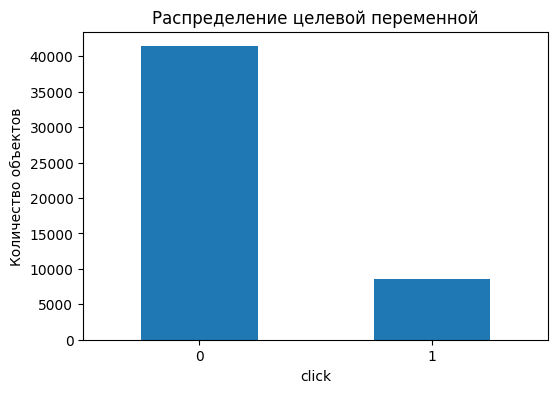

In [63]:
# 2.2 Анализ целевой переменной 

target_dist = df_eda["click"].value_counts().sort_index().to_frame("count")
target_dist["share"] = (target_dist["count"] / len(df_eda)).round(4)
target_dist["share_percent"] = (target_dist["share"] * 100).round(2)

print("Распределение целевой переменной click:")
display(target_dist)

plt.figure(figsize=(6, 4))
target_dist["count"].plot(kind="bar")
plt.title("Распределение целевой переменной")
plt.xlabel("click")
plt.ylabel("Количество объектов")
plt.xticks(rotation=0)
plt.show()

Целевая переменная распределена неравномерно:

В данных присутствует дисбаланс классов, но он не экстремальный. При обучении моделей стоит ориентироваться на PR-AUC, F1, precision, recall, а при необходимости использовать class_weight='balanced'.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Мы обнаружили серьёзный дисбаланс при исследовании данных. Как дополнительные материалы, рекомендую статью <a href='https://dyakonov.org/2021/05/27/imbalance/'>Дисбаланс классов</a>, очень классная, как и весь блог Дьяконова.</font>

In [64]:
# 2.3 Анализ признаков и первичный отбор 

# Списки признаков по смыслу (автоматизировать было бы еще дольше...)
object_cat_cols = df_eda.select_dtypes(include="object").columns.tolist()

categorical_num_cols = [
    "C1", "banner_pos", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21"
]

continuous_num_cols = [
    "ml_feature_1", "ml_feature_3", "ml_feature_5",
    "ml_feature_6", "ml_feature_8", "ml_feature_9", "ml_feature_10",
    "hour_of_day"
]

binary_cols = ["ml_feature_4", "is_weekend"]

temporal_cat_cols = ["day_of_week_num"]

all_categorical_cols = object_cat_cols + categorical_num_cols + temporal_cat_cols + binary_cols

# удаляем id, hour

df_eda.drop(columns=['id', 'hour'], inplace=True)

C:\Users\yanoc\AppData\Local\Temp\ipykernel_16312\1407384342.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cat_cols = df_eda.select_dtypes(include="object").columns.tolist()


In [65]:
# Сводка по признакам
feature_cols = [col for col in df_eda.columns if col != "click"]

feature_info = pd.DataFrame({
    "feature": feature_cols,
    "nunique": [df_eda[col].nunique(dropna=False) for col in feature_cols],
    "unique_ratio": [df_eda[col].nunique(dropna=False) / len(df_eda) for col in feature_cols]
})

def get_feature_group(col):
    if col in binary_cols:
        return "binary"
    elif col in temporal_cat_cols:
        return "temporal_categorical"
    elif col in continuous_num_cols:
        return "continuous_numeric"
    elif col in categorical_num_cols:
        return "categorical_numeric"
    elif col in object_cat_cols:
        return "categorical_object"
    else:
        return "other"

feature_info["group"] = feature_info["feature"].apply(get_feature_group)

display(feature_info.sort_values(["group", "nunique"], ascending=[True, False]))


,feature,nunique,unique_ratio,group
24,ml_feature_4,2,0.00004,binary
34,is_weekend,2,0.00004,binary
13,C14,1497,0.02994,categorical_numeric
16,C17,387,0.00774,categorical_numeric
19,C20,149,0.00298,categorical_numeric
18,C19,64,0.00128,categorical_numeric
20,C21,59,0.00118,categorical_numeric
15,C16,9,0.00018,categorical_numeric
14,C15,8,0.00016,categorical_numeric
0,C1,7,0.00014,categorical_numeric


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

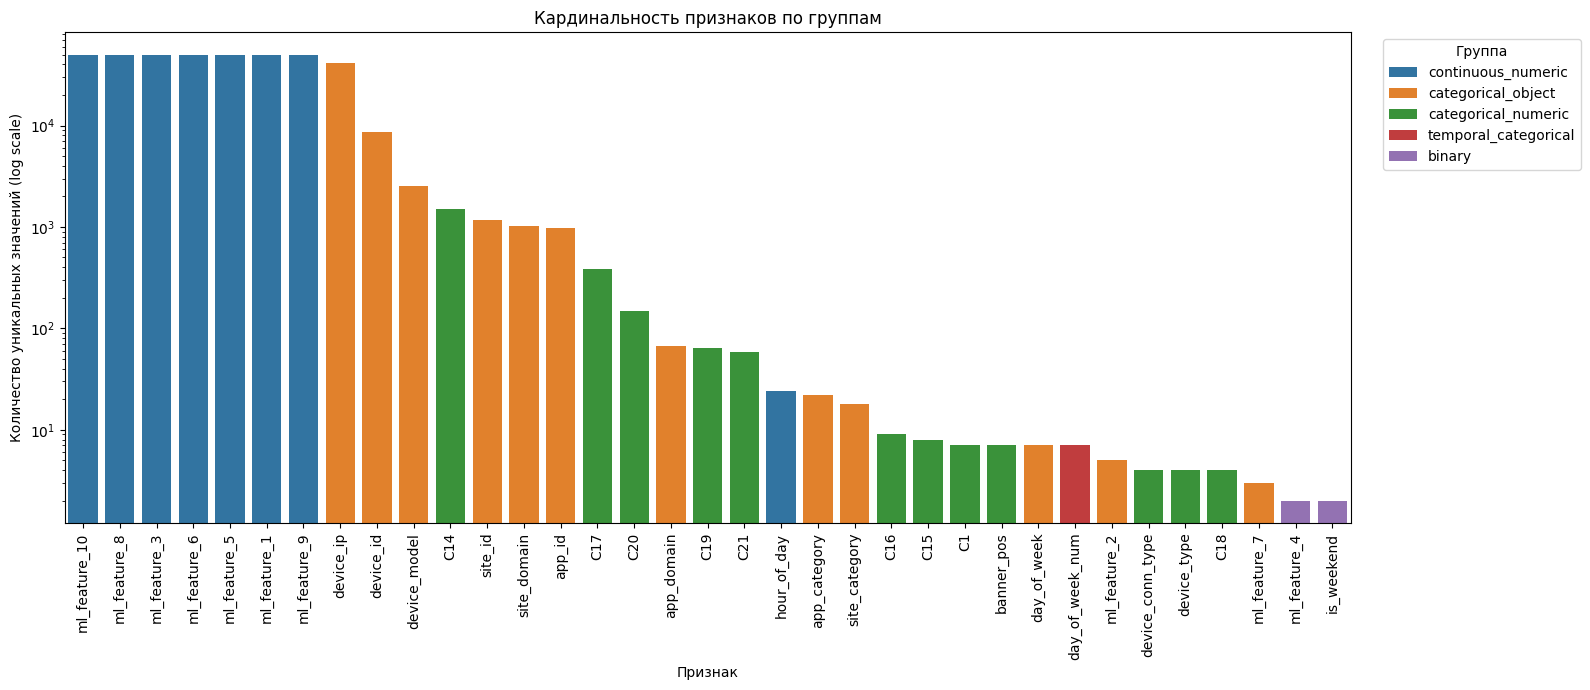

In [66]:
# График кардинальности признаков

plt.figure(figsize=(16, 7))

plot_df = feature_info.sort_values("nunique", ascending=False)

sns.barplot(
    data=plot_df,
    x="feature",
    y="nunique",
    hue="group"
)

plt.yscale("log")
plt.xticks(rotation=90)
plt.xlabel("Признак")
plt.ylabel("Количество уникальных значений (log scale)")
plt.title("Кардинальность признаков по группам")
plt.legend(title="Группа", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Признак id является техническим идентификатором: он почти уникален для каждой строки и не несёт полезного сигнала для обучения, поэтому его нужно удалить.

Признак hour в исходном виде тоже не очень удобен, так как кодирует дату и час в одном числовом поле. Вместо него разумнее использовать производные признаки:

hour_of_day,
day_of_week_num,
is_weekend.

Остальные признаки пока сохраняются: часть из них низкокардинальные категориальные, а часть высококардинальные и потребуют особой обработки.

In [67]:
# 2.4 - уже посмотрели, что пропущенных значений нет.

# 2.5 Анализ категориальных признаков 

categorical_for_cardinality = [
    "site_id", "site_domain", "site_category",
    "app_id", "app_domain", "app_category",
    "device_id", "device_ip", "device_model",
    "ml_feature_2", "ml_feature_7",
    "C1", "banner_pos", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21",
    "day_of_week_num", "ml_feature_4", "is_weekend", "day_of_week"
]

cardinality_table = pd.DataFrame({
    "nunique": df_eda[categorical_for_cardinality].nunique()
}).sort_values("nunique", ascending=False)

display(cardinality_table)

# Значение 22 выбрано эвристичеки (было бы 20, если бы не признак app_category)
ohe_cols = cardinality_table[cardinality_table["nunique"] <= 22].index.tolist()
special_encoding_cols = cardinality_table[cardinality_table["nunique"] > 22].index.tolist()

print("Можно кодировать OHE:")
print(ohe_cols)

print("\nТребуют специальных подходов из-за кардинальности:")
print(special_encoding_cols)

,nunique
device_ip,41455
device_id,8580
device_model,2521
C14,1497
site_id,1160
site_domain,1013
app_id,976
C17,387
C20,149
app_domain,67


Можно кодировать OHE:
['app_category', 'site_category', 'C16', 'C15', 'day_of_week_num', 'day_of_week', 'banner_pos', 'C1', 'ml_feature_2', 'device_type', 'device_conn_type', 'C18', 'ml_feature_7', 'ml_feature_4', 'is_weekend']

Требуют специальных подходов из-за кардинальности:
['device_ip', 'device_id', 'device_model', 'C14', 'site_id', 'site_domain', 'app_id', 'C17', 'C20', 'app_domain', 'C19', 'C21']


,count,mean,std,min,25%,50%,75%,max,iqr,lower,upper,outliers_count,outliers_percent,skew
ml_feature_9,50000.0,0.035361,0.505034,-2.147526,-0.304077,0.035985,0.374152,2.120786,0.678229,-1.321420,1.391495,387,0.77,-0.007409
ml_feature_5,50000.0,0.034729,1.002116,-4.631853,-0.639829,0.028112,0.707594,4.230623,1.347423,-2.660964,2.728728,360,0.72,0.009961
ml_feature_10,50000.0,0.020226,0.303309,-1.287965,-0.182386,0.018930,0.224080,1.202300,0.406467,-0.792087,0.833781,352,0.70,-0.008256
ml_feature_1,50000.0,-0.002445,1.000280,-4.631262,-0.677784,-0.003776,0.673534,3.793828,1.351318,-2.704761,2.700512,347,0.69,0.005473
ml_feature_6,50000.0,0.022948,0.656690,-1.000000,-0.579775,0.037786,0.637131,1.000000,1.216906,-2.405134,2.462490,0,0.00,-0.043951
ml_feature_3,50000.0,-0.036381,5.792335,-9.999742,-5.059555,-0.056155,4.985939,9.999975,10.045494,-20.127795,20.054179,0,0.00,0.009033
ml_feature_8,50000.0,0.025465,0.578026,-0.999965,-0.470627,0.027348,0.521117,1.119858,0.991744,-1.958243,2.008733,0,0.00,-0.009839
hour_of_day,50000.0,11.221500,5.938008,0.000000,6.000000,11.000000,16.000000,23.000000,10.000000,-9.000000,31.000000,0,0.00,0.029364


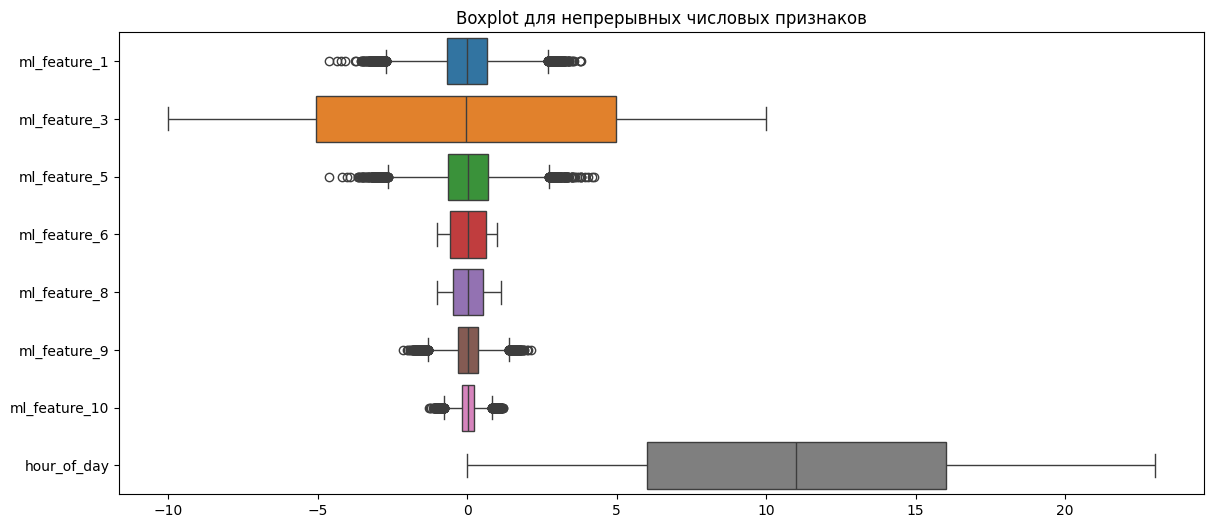

In [68]:
# 2.6 Анализ выбросов и распределений 

outlier_summary = df_eda[continuous_num_cols].describe().T

q1 = df_eda[continuous_num_cols].quantile(0.25)
q3 = df_eda[continuous_num_cols].quantile(0.75)
iqr = q3 - q1

outlier_summary["iqr"] = iqr
outlier_summary["lower"] = q1 - 1.5 * iqr
outlier_summary["upper"] = q3 + 1.5 * iqr
outlier_summary["outliers_count"] = [
    ((df_eda[col] < outlier_summary.loc[col, "lower"]) |
     (df_eda[col] > outlier_summary.loc[col, "upper"])).sum()
    for col in continuous_num_cols
]
outlier_summary["outliers_percent"] = (
    outlier_summary["outliers_count"] / len(df_eda) * 100
).round(2)
outlier_summary["skew"] = df_eda[continuous_num_cols].skew()

display(outlier_summary.sort_values("outliers_percent", ascending=False))

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_eda[continuous_num_cols], orient="h")
plt.title("Boxplot для непрерывных числовых признаков")
plt.show()

Явные выбросы наблюдаются только в части инженерных числовых признаков (ml_feature_1, ml_feature_5, ml_feature_9, ml_feature_10), причём их доля невелика — около 0.7%.

По коэффициенту асимметрии видно, что распределения этих признаков почти симметричны и близки к нормальным, сильного перекоса нет. Поэтому жёсткая обработка выбросов на текущем этапе не требуется; достаточно стандартизации числовых признаков для линейных моделей.

Корреляция числовых признаков с click:


,corr_with_click
ml_feature_9,0.140747
C16,0.130813
ml_feature_10,0.126674
C15,-0.112777
C21,-0.084017
ml_feature_8,0.077923
device_conn_type,-0.076268
C14,-0.072136
ml_feature_6,0.071870
C17,-0.064827


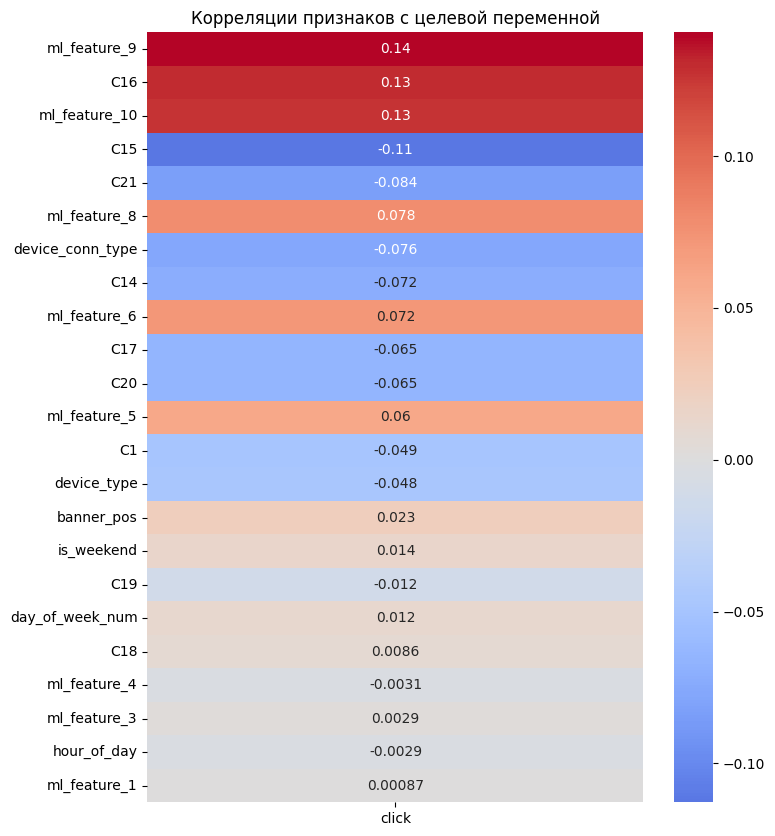

Сильно коррелирующие признаки:


,feature_1,feature_2,abs_corr
128,C14,C17,0.975887
27,C1,device_type,0.899192


In [69]:
# 2.7 Корреляции 

numeric_for_corr = df_eda.select_dtypes(include=np.number).columns.tolist()

corr_with_target = (
    df_eda[numeric_for_corr]
    .corr(method="spearman", numeric_only=True)["click"]
    .drop("click")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Корреляция числовых признаков с click:")
display(corr_with_target.to_frame("corr_with_click").head(15))

plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Корреляции признаков с целевой переменной")
plt.show()

# Поиск сильно коррелирующих между собой признаков
corr_matrix = df_eda[numeric_for_corr].corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] > 0.8]
print("Сильно коррелирующие признаки:")
display(high_corr_pairs)

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>Большинство признаков распределено не нормально, поэтому здесь нужно использовать корреляцию Спирмана или Phik или иные подходы, которые устойчивы к выбросам и ненормальному распределению. Корреляция Пирсона, которая здесь используется по умолчанию, нам не подходит.</font>

</span><br><span style="color: purple; font-weight: bold">Заменил на коэффициент Спирмана</span>

Наиболее заметная монотонная связь с целевой переменной `click` среди числовых признаков наблюдается у `ml_feature_9` (~ 0.141), `C16` (~ 0.131), `ml_feature_10` (~ 0.127), `C15` (~ -0.113), `C21` (~ -0.084), `ml_feature_8` (~ 0.078), `device_conn_type` (~ -0.076), `C14` (~ -0.072) и `ml_feature_6` (~ 0.072).

При этом по абсолютной величине все коэффициенты корреляции Спирмана остаются слабыми, то есть ни один отдельный числовой признак не имеет сильной связи с целевой переменной, однако часть признаков может быть полезна в комбинации с другими.

Среди самих признаков выявлены пары с высокой корреляцией: `C14` и `C17` (~ 0.976), а также `C1` и `device_type` (~ 0.899). Это может указывать на частичное дублирование информации, поэтому на этапе отбора признаков для линейных и интерпретируемых моделей можно рассмотреть сохранение только одного признака из каждой такой пары.

### 2.8 Выводы по EDA

По результатам EDA можно сделать следующие выводы.

Датасет содержит **50 000 наблюдений** и относится к задаче **бинарной классификации**: требуется предсказать вероятность клика по рекламному объявлению. Целевая переменная имеет **умеренный дисбаланс классов**: доля кликов составляет **17.21%**, а доля некликов — **82.79%**.

Пропущенные значения в данных отсутствуют, поэтому специальная обработка `missing values` не требуется. Однако в итоговом пайплайне разумно оставить `SimpleImputer` как защитный механизм на случай появления пропусков в новых данных.

На этапе первичного отбора был удалён признак `id`, поскольку он является техническим идентификатором и не несёт полезной информации для обучения модели. Признак `hour` был преобразован в более интерпретируемые временные признаки: `hour_of_day`, `day_of_week_num`, `is_weekend`. Такая трансформация оправдана, поскольку CTR зависит от времени показа объявления.

В датасете присутствуют две группы категориальных признаков:

- **низкокардинальные признаки**, для которых подходит `One-Hot Encoding`;
- **высококардинальные признаки**, для которых предпочтительнее использовать специальные методы кодирования.

Среди числовых признаков существенных проблем с выбросами не обнаружено: распределения в целом близки к симметричным, а доля выбросов невелика. Поэтому на данном этапе достаточно стандартной масштабировки числовых признаков.

Анализ корреляций показал, что наиболее перспективными для модели выглядят признаки `ml_feature_9`, `ml_feature_10`, `C16`, `device_conn_type`, `ml_feature_8`, `ml_feature_6`, а также временные признаки, полученные из `hour`. Кроме того, были выявлены сильно скоррелированные пары `C14–C17` и `C1–device_type`, что следует учитывать на этапе отбора признаков.

#### Следующие шаги предобработки

1. Выполнить `train/test split` со стратификацией по `click`.
2. Разделить признаки на:
   - числовые,
   - низкокардинальные категориальные,
   - высококардинальные категориальные.
3. Для числовых признаков применить масштабирование.
4. Для низкокардинальных категориальных признаков использовать `One-Hot Encoding`.
5. Для высококардинальных признаков выбрать более устойчивый способ кодирования.
6. Проверить влияние сильно коррелирующих признаков на качество модели.

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [70]:
# 3.1 Разделение данных
X = df_eda.drop(columns=["click", "day_of_week"])  # day_of_week удаляем, так как он дублирует day_of_week_num
y = df_eda["click"]

# Сначала отделяем тестовую выборку
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Затем из оставшихся данных выделяем отдельную калибровочную выборку
X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,   
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Размеры выборок:")
print("X_train:", X_train.shape)
print("X_calib:", X_calib.shape)
print("X_test:", X_test.shape)

Размеры выборок:
X_train: (30000, 34)
X_calib: (10000, 34)
X_test: (10000, 34)


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

In [71]:
# 3.2 Проверка разделения

print("Распределение целевой переменной в обучающей выборке:")
display(y_train.value_counts(normalize=True).to_frame("share").round(4))    

print("\nРаспределение целевой переменной в тестовой выборке:")
display(y_test.value_counts(normalize=True).to_frame("share").round(4))     

print("\nРазмеры выборок:")
print(f"Обучающая выборка: {X_train.shape[0]}")
print(f"Тестовая выборка: {X_test.shape[0]}")


Распределение целевой переменной в обучающей выборке:


,share
click,
0,0.8279
1,0.1721



Распределение целевой переменной в тестовой выборке:


,share
click,
0,0.8279
1,0.1721



Размеры выборок:
Обучающая выборка: 30000
Тестовая выборка: 10000


### Вывод по разделу 3:

Датафрейм был разделен на обучающую, калибровочную и тестовую выборки в соотношении 80/20/20. Распределение целевой переменной сохранилось

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [72]:
# Формируем списки уже после train split и EDA, ориентируясь на X_train, а не на df_eda

object_cat_cols = X_train.select_dtypes(include="object").columns.tolist()

categorical_num_cols = [
    "C1", "banner_pos", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21"
]

# непрерывные числовые признаки
continuous_num_cols = [
    "ml_feature_1", "ml_feature_3", "ml_feature_5",
    "ml_feature_6", "ml_feature_8", "ml_feature_9", "ml_feature_10"
]

# Бинарные признаки
binary_cols = ["ml_feature_4", "is_weekend"]

# Временные категориальные признаки
temporal_cat_cols = ["day_of_week_num", "hour_of_day"]

all_categorical_cols = object_cat_cols + categorical_num_cols + temporal_cat_cols + binary_cols

C:\Users\yanoc\AppData\Local\Temp\ipykernel_16312\4239642365.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cat_cols = X_train.select_dtypes(include="object").columns.tolist()


In [73]:
cardinality_table = pd.DataFrame({
    "nunique": X_train[all_categorical_cols].nunique(dropna=False)
})

# Признаки, которые хотим оставить в OHE принудительно, даже если у них кардинальность чуть выше порога
force_ohe_cols = ["day_of_week_num", "hour_of_day", "ml_feature_4", "is_weekend"]

# Порог выбран эвристически
special_encoding_cols = cardinality_table[cardinality_table["nunique"] > 22].index.tolist()
special_encoding_cols = [col for col in special_encoding_cols if col not in force_ohe_cols]

ohe_cols = [col for col in all_categorical_cols if col not in special_encoding_cols]

print("Признаки для OHE:")
print(ohe_cols)

print("\nПризнаки для Target Encoding:")
print(special_encoding_cols)

Признаки для OHE:
['site_category', 'app_category', 'ml_feature_2', 'ml_feature_7', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'day_of_week_num', 'hour_of_day', 'ml_feature_4', 'is_weekend']

Признаки для Target Encoding:
['site_id', 'site_domain', 'app_id', 'app_domain', 'device_id', 'device_ip', 'device_model', 'C14', 'C17', 'C19', 'C20', 'C21']


In [74]:
# 4.1 , 4.2

# Числовые признаки для стандартизации

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Категориальные признаки для OHE
ohe_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

# Категориальные признаки для таргет-энкодинга
target_encoding_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_encode", TargetEncoder(random_state=RANDOM_STATE))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, continuous_num_cols),
    ("ohe", ohe_pipeline, ohe_cols),
    ("target_enc", target_encoding_pipeline, special_encoding_cols)

])


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Вывод по разделу 4

Для предобработки данных были сформированы отдельные группы признаков на основе обучающей выборки `X_train`. 

Для числовых признаков был построен пайплайн, включающий:
- заполнение пропусков медианой;
- стандартизацию с помощью `StandardScaler`.

Отдельная обработка выбросов не выполнялась, так как на этапе EDA было установлено, что доля выбросов невелика, а их влияние может быть частично снижено масштабированием признаков.

Для категориальных признаков был выполнен отдельный анализ кардинальности по `X_train`, после чего признаки были разделены на две группы:
- признаки с низкой кардинальностью кодируются с помощью `OneHotEncoder`;
- признаки с высокой кардинальностью кодируются с помощью `TargetEncoder`.

При этом временные и бинарные признаки, такие как `day_of_week_num`, `hour_of_day`, `ml_feature_4` и `is_weekend`, были сохранены в группе One-Hot Encoding, поскольку они имеют ограниченное число значений и интерпретируются как категориальные, а не как непрерывные числовые признаки.

Все преобразования объединены в общий `ColumnTransformer`, который включает:
- числовой пайплайн для непрерывных признаков;
- пайплайн One-Hot Encoding для категориальных признаков с небольшой кардинальностью;
- пайплайн Target Encoding для высококардинальных категориальных признаков.

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [75]:
# Преобразуем данные

X_train_prepared = preprocessor.fit_transform(X_train, y_train)
X_test_prepared = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

# Переводим в DataFrame для удобства анализа
X_train_prepared_df = pd.DataFrame(
    X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared,
    columns=feature_names,
    index=X_train.index
)

X_test_prepared_df = pd.DataFrame(
    X_test_prepared.toarray() if hasattr(X_test_prepared, "toarray") else X_test_prepared,
    columns=feature_names,
    index=X_test.index
)

In [76]:
# 5.1 

# Отбираем константные признаки

variance_threshold = 0.001 # значение порога также подбираем эвристически, исходя из того, что применяли StandardScaler

var_selector = VarianceThreshold(threshold=variance_threshold)
X_train_var = var_selector.fit_transform(X_train_prepared_df)
X_test_var = var_selector.transform(X_test_prepared_df)

var_mask = var_selector.get_support()

features_after_variance = X_train_prepared_df.columns[var_mask]
removed_low_variance_features = X_train_prepared_df.columns[~var_mask]

X_train_var_df = pd.DataFrame(
    X_train_var,
    columns=features_after_variance,
    index=X_train.index
)

X_test_var_df = pd.DataFrame(
    X_test_var,
    columns=features_after_variance,
    index=X_test.index
)

variance_table = pd.DataFrame({
    "feature": X_train_prepared_df.columns,
    "variance": X_train_prepared_df.var().values,
    "kept_after_variance_threshold": var_mask
}).sort_values("variance")

print(f"Количество признаков до VarianceThreshold: {X_train_prepared_df.shape[1]}")
print(f"Количество признаков после VarianceThreshold: {X_train_var_df.shape[1]}")
print(f"Удалено низковариативных признаков: {len(removed_low_variance_features)}")

display(variance_table.head(15))

Количество признаков до VarianceThreshold: 139
Количество признаков после VarianceThreshold: 107
Удалено низковариативных признаков: 32


,feature,variance,kept_after_variance_threshold
35,ohe__app_category_a7fd01ec,0.000033,False
75,ohe__C15_480,0.000033,False
84,ohe__C16_320,0.000033,False
11,ohe__site_category_42a36e14,0.000033,False
71,ohe__C15_120,0.000033,False
79,ohe__C16_20,0.000033,False
27,ohe__app_category_18b1e0be,0.000033,False
18,ohe__site_category_a818d37a,0.000033,False
28,ohe__app_category_2281a340,0.000067,False
87,ohe__C16_1024,0.000067,False


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Топ признаков по абсолютной корреляции с целевой переменной:


,feature,corr_with_target,abs_corr_with_target
103,target_enc__C17,0.233348,0.233348
102,target_enc__C14,0.218909,0.218909
96,target_enc__site_id,0.218907,0.218907
97,target_enc__site_domain,0.201546,0.201546
106,target_enc__C21,0.184426,0.184426
104,target_enc__C19,0.156846,0.156846
59,ohe__C18_2,0.154077,0.154077
55,ohe__C16_250,0.151948,0.151948
5,num__ml_feature_9,0.143477,0.143477
53,ohe__C16_50,-0.134099,0.134099


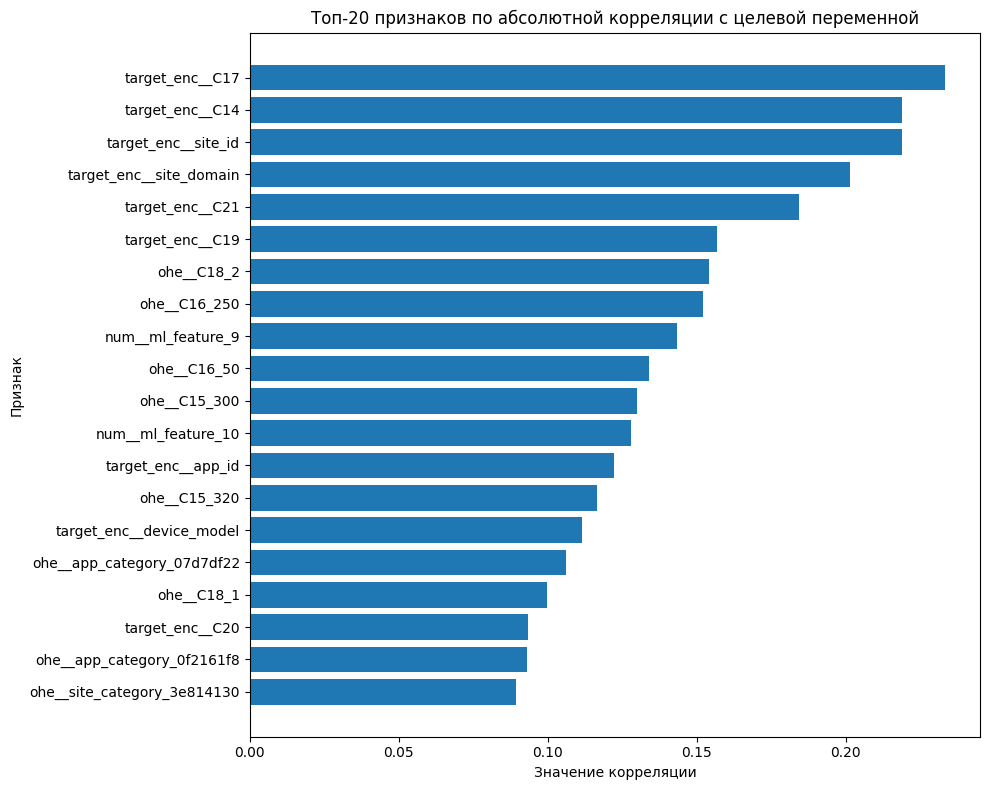

In [77]:
# Считаем корреляцию каждого оставшегося признака с целевой переменной

corr_with_target = X_train_var_df.apply(lambda col: col.corr(y_train, method="spearman")).fillna(0)

corr_table = pd.DataFrame({
    "feature": X_train_var_df.columns,
    "corr_with_target": corr_with_target.values,
    "abs_corr_with_target": corr_with_target.abs().values
}).sort_values("abs_corr_with_target", ascending=False)

print("Топ признаков по абсолютной корреляции с целевой переменной:")
display(corr_table.head(20))

# Визуализируем топ-20 

top_n_plot = 20
plot_data = corr_table.head(top_n_plot).sort_values("abs_corr_with_target")

plt.figure(figsize=(10, 8))
plt.barh(plot_data["feature"], plot_data["abs_corr_with_target"])
plt.title("Топ-20 признаков по абсолютной корреляции с целевой переменной")
plt.xlabel("Значение корреляции")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

In [78]:
# Новый раздел (от 6.4)

def abs_corr_score(X, y):
    return np.abs(r_regression(X, y))

# Добавляем SelectKBest

candidate_k = [30, 40, 50, 60, 80]

kbest_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=RANDOM_STATE
)

cv_kbest = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

kbest_results = []

for k in candidate_k:
    selector = SelectKBest(score_func=abs_corr_score, k=k)
    X_train_k_candidate = selector.fit_transform(X_train_var_df, y_train)

    cv_score = cross_val_score(
        estimator=kbest_model,
        X=X_train_k_candidate,
        y=y_train,
        cv=cv_kbest,
        scoring="average_precision",
        n_jobs=-1
    ).mean()

    kbest_results.append({
        "k": k,
        "cv_average_precision": cv_score
    })

kbest_results_df = pd.DataFrame(kbest_results).sort_values(
    "cv_average_precision",
    ascending=False
).reset_index(drop=True)

display(kbest_results_df)

,k,cv_average_precision
0,50,0.413042
1,60,0.412796
2,80,0.412665
3,40,0.412453
4,30,0.409822


In [79]:
# Финальный отбор признаков с помощью SelectKBest (Полностью заменили ячейку, которая была до этого)

best_k = int(kbest_results_df.iloc[0]["k"])

kbest_selector = SelectKBest(score_func=abs_corr_score, k=best_k)

X_train_kbest = kbest_selector.fit_transform(X_train_var_df, y_train)
X_test_kbest = kbest_selector.transform(X_test_var_df)

selected_features_kbest = X_train_var_df.columns[kbest_selector.get_support()].tolist()

X_train_kbest = pd.DataFrame(
    X_train_kbest,
    columns=selected_features_kbest,
    index=X_train.index
)

X_test_kbest = pd.DataFrame(
    X_test_kbest,
    columns=selected_features_kbest,
    index=X_test.index
)

print(f"Лучшее значение k по CV: {best_k}")
print(f"Количество признаков после SelectKBest: {len(selected_features_kbest)}")
display(pd.DataFrame({"selected_feature": selected_features_kbest}).head(20))

Лучшее значение k по CV: 50
Количество признаков после SelectKBest: 50


,selected_feature
0,num__ml_feature_5
1,num__ml_feature_6
2,num__ml_feature_8
3,num__ml_feature_9
4,num__ml_feature_10
5,ohe__site_category_28905ebd
6,ohe__site_category_3e814130
7,ohe__site_category_50e219e0
8,ohe__site_category_76b2941d
9,ohe__site_category_f028772b


#### Вывод по разделу 5.1

На первом этапе отбора признаков были применены фильтрационные методы.

Сначала данные обучающей выборки были преобразованы с помощью пайплайна предобработки, после чего был получен расширенный набор признаков после масштабирования, One-Hot Encoding и Target Encoding.

Далее был применён метод `VarianceThreshold` с порогом `0.001`. Он позволил удалить признаки с очень низкой вариацией, то есть почти константные признаки, которые практически не различают объекты и слабо полезны для модели.

После этого для оставшихся признаков была рассчитана корреляция с целевой переменной `click`, что позволило предварительно оценить силу связи признаков с таргетом.

Затем был исследован метод `SelectKBest` с пользовательской функцией `abs_corr_score`, основанной на абсолютной величине корреляции признаков с целевой переменной. Были проверены несколько вариантов количества признаков (`k`), а качество оценивалось с помощью кросс-валидации по метрике `average precision`.

По результатам сравнения было выбрано лучшее значение `k`, после чего сформирован итоговый набор признаков после фильтрационного отбора. Такой подход позволяет не просто эвристически выбрать число признаков, а обосновать его качеством модели на кросс-валидации.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [80]:
# 5.2 Методы обертки

# Базовая модель для RFE
base_estimator = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

# Проверяем несколько вариантов количества признаков
candidate_n_features = [30, 40, 50] # 30 и 50 оставляю для доказательства того, что пробовал перебирать

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

wrapper_results = []

for n_features in candidate_n_features:
    rfe = RFE(
        estimator=base_estimator,
        n_features_to_select=n_features,
        step=1
    )
    
    X_train_rfe_candidate = rfe.fit_transform(X_train_kbest, y_train)
    
    cv_score = cross_val_score(
        estimator=base_estimator,
        X=X_train_rfe_candidate,
        y=y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    ).mean()
    
    wrapper_results.append({
        "n_features": n_features,
        "cv_average_precision": cv_score
    })

wrapper_results_df = pd.DataFrame(wrapper_results).sort_values(
    "cv_average_precision",
    ascending=False
)

display(wrapper_results_df)

,n_features,cv_average_precision
1,40,0.413867
2,50,0.413042
0,30,0.394078


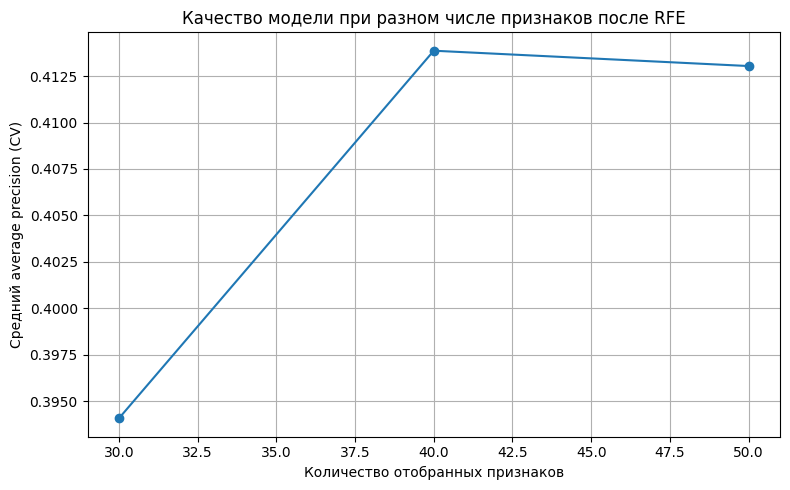

In [81]:
# Визуализация 

plot_df = wrapper_results_df.sort_values("n_features")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["n_features"], plot_df["cv_average_precision"], marker="o")
plt.title("Качество модели при разном числе признаков после RFE")
plt.xlabel("Количество отобранных признаков")
plt.ylabel("Средний average precision (CV)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [82]:
# Обучаем финальный RFE на всём train

final_rfe = RFE(
    estimator=base_estimator,
    n_features_to_select=int(wrapper_results_df.iloc[0]["n_features"]),
    step=1
)

X_train_wrapper = final_rfe.fit_transform(X_train_kbest, y_train)
X_test_wrapper = final_rfe.transform(X_test_kbest)

selected_features_wrapper = X_train_kbest.columns[final_rfe.support_].tolist()

print(f"Количество признаков после RFE: {X_train_wrapper.shape[1]}")

selected_features_wrapper_df = pd.DataFrame({
    "selected_feature": selected_features_wrapper
})

display(selected_features_wrapper_df)

Количество признаков после RFE: 40


,selected_feature
0,num__ml_feature_5
1,num__ml_feature_6
2,num__ml_feature_8
3,num__ml_feature_9
4,num__ml_feature_10
5,ohe__site_category_28905ebd
6,ohe__site_category_3e814130
7,ohe__site_category_50e219e0
8,ohe__site_category_76b2941d
9,ohe__site_category_f028772b


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Вывод по разделу 5.2

На втором этапе отбора признаков был применён метод-обёртка `RFE` (Recursive Feature Elimination) с базовой моделью `LogisticRegression`.

В отличие от фильтрационных методов, которые оценивают признаки независимо, метод RFE учитывает их полезность в рамках конкретной модели. Алгоритм последовательно обучает модель, оценивает значимость признаков и удаляет наименее важные, пока не останется заданное число признаков.

Для выбора оптимального размера итогового набора были рассмотрены несколько вариантов количества признаков. Для каждого варианта качество модели оценивалось с помощью кросс-валидации по метрике `average precision`.

По результатам сравнения было выбрано то количество признаков, при котором достигается наилучшее качество на кросс-валидации. После этого на всей обучающей выборке был обучен финальный RFE, и сформирован окончательный набор наиболее значимых признаков.

Таким образом, после предварительного фильтрационного отбора из раздела 5.1 был выполнен более точный отбор признаков методом-обёрткой, что позволило получить компактное и информативное признаковое пространство для построения итоговой модели.

In [83]:
# 5.3

# Преобразуем результат RFE в DataFrame для удобства
X_train_wrapper_df = pd.DataFrame(
    X_train_wrapper,
    columns=selected_features_wrapper,
    index=X_train.index
)

X_test_wrapper_df = pd.DataFrame(
    X_test_wrapper,
    columns=selected_features_wrapper,
    index=X_test.index
)

# Базовая модель для сравнения наборов признаков
comparison_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

feature_sets = {
    "All features after preprocessing": X_train_prepared_df,
    "After filter methods": X_train_kbest,
    "After wrapper methods (RFE)": X_train_wrapper_df
}

comparison_results = []

for feature_set_name, X_fs in feature_sets.items():
    scores = cross_validate(
        estimator=comparison_model,
        X=X_fs,
        y=y_train,
        cv=cv,
        scoring={
            "pr_auc": "average_precision",
            "log_loss": "neg_log_loss",
            "brier": "neg_brier_score"
        },
        n_jobs=-1
    )
    
    comparison_results.append({
        "feature_set": feature_set_name,
        "n_features": X_fs.shape[1],
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "cv_log_loss": -scores["test_log_loss"].mean(),
        "cv_brier_score": -scores["test_brier"].mean()
    })

comparison_results_df = pd.DataFrame(comparison_results)

comparison_results_df = comparison_results_df.sort_values(
    by=["cv_pr_auc", "cv_log_loss", "cv_brier_score"],
    ascending=[False, True, True]
).reset_index(drop=True)

display(comparison_results_df)

,feature_set,n_features,cv_pr_auc,cv_log_loss,cv_brier_score
0,After wrapper methods (RFE),40,0.413867,0.393352,0.122574
1,After filter methods,50,0.413042,0.393653,0.122670
2,All features after preprocessing,139,0.412143,0.394680,0.122858


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Вывод по разделу 5.3

На заключительном этапе отбора признаков были сопоставлены три варианта признакового пространства:

1. полный набор признаков после препроцессинга;
2. набор признаков после фильтрационных методов;
3. набор признаков после применения метода-обёртки RFE.

Сравнение выполнялось на обучающей выборке с помощью кросс-валидации. Для оценки использовались метрики, указанные в задании проекта: **PR-AUC** как основная метрика, а также **Log Loss** и **Brier score** для оценки качества вероятностных предсказаний и калибровки модели.

Основным критерием выбора являлась метрика **PR-AUC**, так как задача относится к несбалансированной бинарной классификации, где особенно важно качество выявления положительного класса. Метрики **Log Loss** и **Brier score** использовались как дополнительные показатели качества вероятностного прогноза.

По результатам сравнения был выбран лучший набор признаков, который обеспечивает наилучшее соотношение между качеством классификации, точностью вероятностных оценок и компактностью признакового пространства. Именно этот набор будет использоваться далее при обучении итоговой модели.

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

In [84]:
# Создание функций для подготовки данных

def make_preprocessor_cv():
    num_pipeline_cv = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    ohe_pipeline_cv = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    target_encoding_pipeline_cv = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target_encode", TargetEncoder(random_state=RANDOM_STATE))
    ])

    return ColumnTransformer([
        ("num", num_pipeline_cv, continuous_num_cols),
        ("ohe", ohe_pipeline_cv, ohe_cols),
        ("target_enc", target_encoding_pipeline_cv, special_encoding_cols)
    ], verbose_feature_names_out=True).set_output(transform="pandas")

def make_model_pipeline(model):
    return Pipeline([
        ("preprocessor", make_preprocessor_cv()),
        ("variance", VarianceThreshold(threshold=0.001).set_output(transform="pandas")),
        ("corr", SelectKBest(score_func=abs_corr_score, k=50).set_output(transform="pandas")),
        ("rfe", RFE(
            estimator=LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                random_state=RANDOM_STATE
            ),
            n_features_to_select=40,
            step=1
        ).set_output(transform="pandas")),
        ("model", model)
    ])

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">SelectKBest не исследовался при отборе признаков. Нужно включить его в шаг 5. Отбор признаков, если он применяется в модели. </span>

</span><br><span style="color: purple; font-weight: bold">Исправил. Добавил SelectKBest в Шаг 5 (k=50). Также немного изменил названия переменных + переместил функцию abs_corr_score в 5 раздел из 6.</span>

In [85]:
# 6.1-6.3

# Подготовка моделей

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

dummy_model = DummyClassifier(strategy="prior")

logreg_pipeline = make_model_pipeline(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    )
)

svc_pipeline = make_model_pipeline(
    SVC(
        kernel="linear",
        probability=False,
        random_state=RANDOM_STATE
    )
)


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Классно, что сравниваешь с константной моделью!</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Для DummyClassifier не нужен препроцессор. Он полностью игнорирует X.</font>

</span><br><span style="color: purple; font-weight: bold">Убрал - оставил только саму модель</span>

In [86]:
# 6.4

# Функция для оценки модели

def evaluate_model(model_name, estimator, X, y, cv, scoring):
    scores = cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        "model": model_name,
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean()
    }

section6_results = []

section6_results.append(
    evaluate_model("DummyClassifier", dummy_model, X_train, y_train, cv, scoring)
)

section6_results.append(
    evaluate_model("LogisticRegression", logreg_pipeline, X_train, y_train, cv, scoring)
)

section6_results.append(
    evaluate_model("SVC (linear kernel)", svc_pipeline, X_train, y_train, cv, scoring)
)

section6_results_df = (
    pd.DataFrame(section6_results)
    .sort_values("cv_pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(section6_results_df)

,model,cv_pr_auc,cv_precision,cv_recall,cv_f1
0,LogisticRegression,0.413857,0.614283,0.142584,0.23126
1,SVC (linear kernel),0.325698,0.000000,0.000000,0.00000
2,DummyClassifier,0.172067,0.000000,0.000000,0.00000


### Вывод по разделу 6

В данном разделе было проведено сравнение трёх базовых моделей классификации: `DummyClassifier`, `LogisticRegression` и `SVC` с линейным ядром.  
Оценка качества выполнялась с помощью кросс-валидации на обучающей выборке, при этом предобработка и отбор признаков для основных моделей были включены в единый `Pipeline`, что обеспечивает корректность оценки и исключает утечку данных между фолдами.

В качестве основной метрики использовалась `PR-AUC`, поскольку задача является несбалансированной, и эта метрика лучше отражает качество модели на положительном классе.

Полученные результаты:

- `LogisticRegression`: `PR-AUC = 0.4139`, `Precision = 0.6143`, `Recall = 0.1426`, `F1 = 0.2313`
- `SVC (linear kernel)`: `PR-AUC = 0.3257`, `Precision = 0.0000`, `Recall = 0.0000`, `F1 = 0.0000`
- `DummyClassifier`: `PR-AUC = 0.1721`, `Precision = 0.0000`, `Recall = 0.0000`, `F1 = 0.0000`

Наилучший результат по основной метрике показала модель **LogisticRegression**.  
Она существенно превосходит наивный baseline в лице `DummyClassifier`, а также показывает более высокое качество по сравнению с `SVC`.

Следует отметить, что модель `SVC` продемонстрировала `PR-AUC` выше baseline, однако при стандартном пороге классификации не предсказывала положительный класс, из-за чего значения `Precision`, `Recall` и `F1-score` оказались равны нулю. Это говорит о том, что модель способна ранжировать объекты лучше случайной, но в текущей конфигурации уступает логистической регрессии как по основной метрике, так и по практической применимости.

Таким образом, для дальнейшей настройки гиперпараметров в следующем разделе целесообразно выбрать модель **LogisticRegression**.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> Закомментированный код лучше удалять из проекта. Он создаёт впечатление неоконченой работы.</font>

</span><br><span style="color: purple; font-weight: bold">Удалил</span>

In [ ]:
# 7.1

# тоже сократил, иначе ждать приходится почти 10 минут
param_grid_logreg = {
    "model__C": [0.05, 0.1, 0.5, 1, 10], 
    "model__penalty": ["l1", "l2"], 
    "model__class_weight": ["balanced"] # тут еще было None
}

param_grid_svc = {
    "model__C": [0.1, 0.5], 
    "model__class_weight": ["balanced"] # тут еще было None
}

models_and_grids = {
    "LogisticRegression": {
        "pipeline": logreg_pipeline,
        "param_grid": param_grid_logreg
    },
    "SVC (linear kernel)": {
        "pipeline": svc_pipeline,
        "param_grid": param_grid_svc
    }
}

#### Вывод по пункту 7.1

Для модели `LogisticRegression` в сетку гиперпараметров включены (Всего 10):
- `C` — коэффициент регуляризации;
- `penalty` — тип регуляризации (`l1` или `l2`);
- `class_weight` — способ учёта дисбаланса классов.

Для модели `SVC` с линейным ядром в сетку гиперпараметров включены (Всего 2):
- `C` — коэффициент регуляризации;
- `class_weight` — способ учёта дисбаланса классов.

Выбор именно этих параметров обусловлен тем, что они напрямую влияют на обобщающую способность моделей и особенно важны в задаче несбалансированной бинарной классификации.  

In [88]:
# 7.2

# Еще раз задаем cv
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE) # n_splits тоже уменьшил с 5 до 3

grid_search_logreg = GridSearchCV(
    estimator=models_and_grids["LogisticRegression"]["pipeline"],
    param_grid=models_and_grids["LogisticRegression"]["param_grid"],
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search_svc = GridSearchCV(
    estimator=models_and_grids["SVC (linear kernel)"]["pipeline"],
    param_grid=models_and_grids["SVC (linear kernel)"]["param_grid"],
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search_logreg.fit(X_train, y_train)
grid_search_svc.fit(X_train, y_train)

print("LogisticRegression")
print("Лучшие параметры:", grid_search_logreg.best_params_)
print("Лучшая метрика average_precision:", grid_search_logreg.best_score_)
print()

print("SVC (linear kernel)")
print("Лучшие параметры:", grid_search_svc.best_params_)
print("Лучшая метрика average_precision:", grid_search_svc.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits
LogisticRegression
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Лучшая метрика average_precision: 0.41493938863486407

SVC (linear kernel)
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Лучшая метрика average_precision: 0.4113104250139392


In [89]:
# 7.3. Топ-10 конфигураций

logreg_results_73 = pd.DataFrame(grid_search_logreg.cv_results_).copy()
svc_results_73 = pd.DataFrame(grid_search_svc.cv_results_).copy()

logreg_top = logreg_results_73[
    [
        "mean_test_score", "std_test_score", "rank_test_score",
        "param_model__C", "param_model__class_weight", "param_model__penalty"
    ]
].copy()
logreg_top["model"] = "LogisticRegression"

svc_top = svc_results_73[
    [
        "mean_test_score", "std_test_score", "rank_test_score",
        "param_model__C", "param_model__class_weight"
    ]
].copy()
svc_top["param_model__penalty"] = "-"
svc_top["model"] = "SVC (linear kernel)"

top10_results = pd.concat([logreg_top, svc_top], ignore_index=True)

top10_results = top10_results[
    [
        "model",
        "mean_test_score",
        "std_test_score",
        "param_model__C",
        "param_model__class_weight",
        "param_model__penalty"
    ]
].sort_values("mean_test_score", ascending=False).head(10)

top10_results = top10_results.rename(columns={
    "mean_test_score": "mean_cv_average_precision",
    "std_test_score": "std_cv_average_precision",
    "param_model__C": "C",
    "param_model__class_weight": "class_weight",
    "param_model__penalty": "penalty"
}).reset_index(drop=True)

display(top10_results)

,model,mean_cv_average_precision,std_cv_average_precision,C,class_weight,penalty
0,LogisticRegression,0.414939,0.006362,0.10,balanced,l2
1,LogisticRegression,0.414886,0.006853,0.50,balanced,l2
2,LogisticRegression,0.414721,0.006890,1.00,balanced,l2
3,LogisticRegression,0.414398,0.006874,10.00,balanced,l2
4,LogisticRegression,0.414154,0.006023,0.05,balanced,l2
5,SVC (linear kernel),0.411310,0.005447,0.10,balanced,-
6,SVC (linear kernel),0.410339,0.006395,0.50,balanced,-


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red"> Нужна табличка из 10 Лучших моделей. </span>
> 7.3 Составьте таблицу результатов
>- Покажите топ-10 конфигураций с их метриками.

</span><br><span style="color: purple; font-weight: bold">Добавил топ-10</span>

### Вывод по разделу 7

В данном разделе была выполнена настройка гиперпараметров для моделей `LogisticRegression` и `SVC` с линейным ядром с помощью `GridSearchCV`.  
Поиск проводился на обучающей выборке, при этом предобработка данных и отбор признаков оставались внутри единого `Pipeline`, что обеспечивает корректность кросс-валидации и предотвращает утечку данных.

В качестве целевой метрики при подборе гиперпараметров использовалась `average_precision`, поскольку задача является несбалансированной, а эта метрика наиболее информативна для оценки качества на положительном классе.

По результатам `GridSearchCV` была сформирована сводная таблица лучших протестированных конфигураций моделей `LogisticRegression` и `SVC`, отсортированная по среднему значению `average_precision` на кросс-валидации. Это позволяет сравнить не только лучшие параметры каждой модели, но и несколько близких по качеству конфигураций, что делает выбор финальной модели более обоснованным.

Полученные результаты показали, что наилучшие конфигурации относятся к модели `LogisticRegression`. Лучшая модель имеет параметры:

- `C = 0.1`
- `class_weight = balanced`
- `penalty = l2`

и показывает:

- `mean CV average_precision = 0.4149`
- `std = 0.0064`

Для `SVC (linear kernel)` лучшая конфигурация имеет параметры:

- `C = 0.1`
- `class_weight = balanced`

и показывает:

- `mean CV average_precision = 0.4113`
- `std = 0.0054`

Таким образом, наилучшее значение основной метрики снова показала модель **LogisticRegression**. Ее результат немного выше, чем у `SVC`, что подтверждает вывод предыдущего раздела о том, что логистическая регрессия является наиболее подходящей моделью для дальнейшего использования в рамках данного проекта.

По итогам подбора гиперпараметров в качестве финальной модели для следующего этапа выбирается **LogisticRegression** с параметрами `C = 0.1`, `penalty = l2`, `class_weight = balanced`.

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [90]:
# 8.1 Обучение финальной модели

final_logreg_pipeline = grid_search_logreg.best_estimator_

print("Финальная модель получена из GridSearchCV и уже обучена на всей обучающей выборке.")
print("Лучшие параметры:", grid_search_logreg.best_params_)
print(final_logreg_pipeline)

Финальная модель получена из GridSearchCV и уже обучена на всей обучающей выборке.
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   '

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>GridSearchCV возвращает оптимальную модель уже обученную на всех обучающих данных. `grid_search_logreg.best_estimator_`, например. </font>

</span><br><span style="color: purple; font-weight: bold">Поправил код</span>

In [91]:
# 8.2

y_test_proba = final_logreg_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = final_logreg_pipeline.predict(X_test)

final_test_metrics = pd.DataFrame([{
    "PR-AUC": average_precision_score(y_test, y_test_proba),
    "Brier score": brier_score_loss(y_test, y_test_proba),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba)
}])

display(final_test_metrics)

,PR-AUC,Brier score,Precision,Recall,F1-score,ROC-AUC
0,0.405435,0.198965,0.316676,0.677513,0.431612,0.752754


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

#### Вывод по пункту 8.2

Финальная модель `LogisticRegression`, обученная на всей обучающей выборке с лучшими гиперпараметрами из `GridSearchCV`, была оценена на тестовой выборке.

Полученные результаты:

- `PR-AUC = 0.4054`
- `Brier score = 0.1990`
- `Precision = 0.3167`
- `Recall = 0.6775`
- `F1-score = 0.4316`
- `ROC-AUC = 0.7528`

Модель показывает хорошее качество ранжирования объектов: значение `PR-AUC` заметно выше baseline, а `ROC-AUC` на уровне `0.75` говорит о достаточно уверенном разделении классов.

При использовании стандартного порога классификации модель демонстрирует высокий `Recall`, то есть находит значительную долю реальных кликов, однако делает это ценой умеренного `Precision`. Это означает, что модель склонна чаще относить объект к положительному классу, что в данной задаче может быть оправдано, если важно не пропускать потенциальные клики.

Значение `Brier score = 0.1990` показывает, что вероятностные прогнозы модели в целом разумны, однако пространство для улучшения калибровки по-прежнему остается. Поэтому на следующем этапе целесообразно дополнительно проверить и при необходимости откалибровать вероятности модели.

Топ-15 признаков по модулю коэффициента:


,feature,coefficient,abs_coefficient
0,target_enc__site_id,2.286261,2.286261
1,target_enc__app_id,2.136165,2.136165
2,target_enc__C17,1.541784,1.541784
3,target_enc__site_domain,1.167630,1.167630
4,target_enc__C14,0.914450,0.914450
5,ohe__C18_1,-0.808236,0.808236
6,target_enc__C21,0.778652,0.778652
7,ohe__banner_pos_0,-0.744968,0.744968
8,ohe__app_category_07d7df22,-0.678888,0.678888
9,target_enc__app_domain,0.660818,0.660818


Топ-10 признаков, повышающих вероятность клика:


,feature,coefficient,abs_coefficient
0,target_enc__site_id,2.286261,2.286261
1,target_enc__app_id,2.136165,2.136165
2,target_enc__C17,1.541784,1.541784
3,target_enc__site_domain,1.167630,1.167630
4,target_enc__C14,0.914450,0.914450
5,target_enc__C21,0.778652,0.778652
6,target_enc__app_domain,0.660818,0.660818
7,target_enc__C20,0.541122,0.541122
8,ohe__app_category_f95efa07,0.511289,0.511289
9,target_enc__device_model,0.479867,0.479867


Топ-10 признаков, понижающих вероятность клика:


,feature,coefficient,abs_coefficient
0,ohe__C18_1,-0.808236,0.808236
1,ohe__banner_pos_0,-0.744968,0.744968
2,ohe__app_category_07d7df22,-0.678888,0.678888
3,ohe__site_category_f66779e6,-0.635935,0.635935
4,ohe__banner_pos_1,-0.551680,0.551680
5,ohe__site_category_50e219e0,-0.361508,0.361508
6,ohe__site_category_76b2941d,-0.359249,0.359249
7,ohe__device_type_4,-0.299589,0.299589
8,ohe__C1_1010,-0.229252,0.229252
9,ohe__device_conn_type_3,-0.211961,0.211961


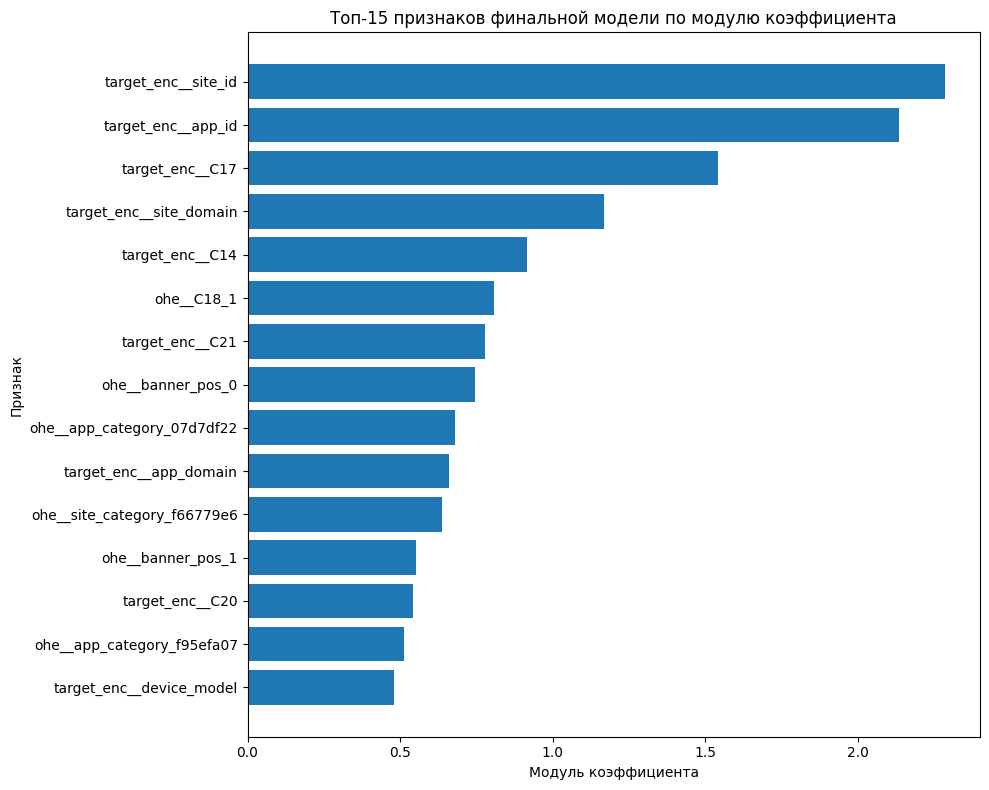

In [92]:
# 8.3

# Получаем итоговое признаковое пространство после всех шагов pipeline, кроме модели
X_train_final_83 = final_logreg_pipeline[:-1].transform(X_train)

# Получаем коэффициенты логистической регрессии
final_coefficients_83 = final_logreg_pipeline.named_steps["model"].coef_[0]

coef_table_83 = pd.DataFrame({
    "feature": X_train_final_83.columns,
    "coefficient": final_coefficients_83
})

coef_table_83["abs_coefficient"] = coef_table_83["coefficient"].abs()
coef_table_83 = coef_table_83.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

top_features_abs_83 = coef_table_83.head(15)
top_positive_features_83 = coef_table_83.sort_values("coefficient", ascending=False).head(10).reset_index(drop=True)
top_negative_features_83 = coef_table_83.sort_values("coefficient", ascending=True).head(10).reset_index(drop=True)

print("Топ-15 признаков по модулю коэффициента:")
display(top_features_abs_83)

print("Топ-10 признаков, повышающих вероятность клика:")
display(top_positive_features_83)

print("Топ-10 признаков, понижающих вероятность клика:")
display(top_negative_features_83)

plot_df_83 = top_features_abs_83.sort_values("abs_coefficient")

plt.figure(figsize=(10, 8))
plt.barh(plot_df_83["feature"], plot_df_83["abs_coefficient"])
plt.title("Топ-15 признаков финальной модели по модулю коэффициента")
plt.xlabel("Модуль коэффициента")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

#### Вывод по пункту 8.3

Анализ коэффициентов финальной модели показал, что наибольшее влияние на предсказание вероятности клика оказывают признаки, полученные после `Target Encoding`.  
Среди них наиболее важными по модулю коэффициентов оказались:

- `target_enc__app_id`
- `target_enc__site_id`
- `target_enc__C17`
- `target_enc__site_domain`
- `target_enc__C14`
- `target_enc__app_domain`

Положительные коэффициенты у этих признаков означают, что более высокие значения соответствующих закодированных категорий увеличивают логарифм отношения шансов клика, а значит и вероятность положительного класса.

Среди признаков с наиболее заметным отрицательным вкладом выделяются:

- `ohe__site_category_f66779e6`
- `ohe__C18_1`
- `ohe__app_category_07d7df22`
- `ohe__banner_pos_0`
- `ohe__banner_pos_1`

Их наличие связано со снижением вероятности клика по сравнению с другими значениями соответствующих признаков.

Также в число значимых признаков вошёл непрерывный числовой признак `num__ml_feature_9`, что согласуется с результатами EDA и отбора признаков, где он уже показывал заметную связь с целевой переменной.

Таким образом, финальная модель в наибольшей степени опирается на информацию о рекламной площадке, приложении, домене и некоторых категориальных технических характеристиках показа. Это выглядит содержательно правдоподобно для задачи прогнозирования CTR, поскольку вероятность клика действительно должна существенно зависеть от контекста размещения объявления и параметров инвентаря.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Вывод по разделу 8

На данном этапе была выбрана и оценена финальная модель `LogisticRegression` с гиперпараметрами, полученными в результате `GridSearchCV`:

- `C = 0.1`
- `penalty = l2`
- `class_weight = balanced`

Поскольку `GridSearchCV` использовался с `refit=True`, лучшая конфигурация была автоматически переобучена на всей обучающей выборке и затем протестирована на отложенной тестовой выборке.

На тестовой выборке модель показала следующие результаты:

- `PR-AUC = 0.4054`
- `Brier score = 0.1990`
- `Precision = 0.3167`
- `Recall = 0.6775`
- `F1-score = 0.4316`
- `ROC-AUC = 0.7528`

Полученные значения показывают, что модель достаточно хорошо разделяет классы и находит значительную долю реальных кликов. При этом умеренное значение `Precision` указывает на наличие ложноположительных срабатываний, что типично для задач с несбалансированными классами и ориентацией на высокий `Recall`.

Анализ коэффициентов показал, что заметный вклад в предсказание вносят признаки, связанные с `app_id`, `site_id`, `site_domain`, `app_domain`, а также некоторые технические характеристики показа. Это выглядит содержательно обоснованным, поскольку вероятность клика действительно зависит от контекста показа объявления и особенностей рекламной площадки.

В целом финальная модель демонстрирует хорошее качество как классификации, так и вероятностного ранжирования, однако значение `Brier score = 0.1990` показывает, что вероятности ещё можно дополнительно улучшить с точки зрения калибровки.

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

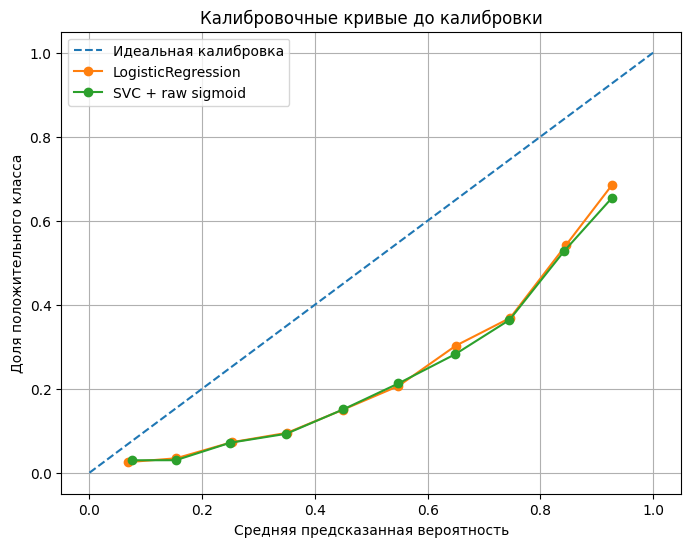

In [93]:
# 9.1

final_svc_pipeline = grid_search_svc.best_estimator_ # тут тоже заменил большой кусок кода (как в разделе 8)

y_test_proba_logreg_91 = final_logreg_pipeline.predict_proba(X_test)[:, 1]

y_test_scores_svc_91 = final_svc_pipeline.decision_function(X_test)
y_test_proba_svc_rawsigmoid_91 = 1 / (1 + np.exp(-y_test_scores_svc_91))

prob_true_logreg_91, prob_pred_logreg_91 = calibration_curve(
    y_test,
    y_test_proba_logreg_91,
    n_bins=10,
    strategy="uniform"
)

prob_true_svc_91, prob_pred_svc_91 = calibration_curve(
    y_test,
    y_test_proba_svc_rawsigmoid_91,
    n_bins=10,
    strategy="uniform"
)

# Визуализация
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Идеальная калибровка")
plt.plot(prob_pred_logreg_91, prob_true_logreg_91, marker="o", label="LogisticRegression")
plt.plot(prob_pred_svc_91, prob_true_svc_91, marker="o", label="SVC + raw sigmoid")

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля положительного класса")
plt.title("Калибровочные кривые до калибровки")
plt.legend()
plt.grid(True)
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [94]:
calibration_table_logreg_91 = pd.DataFrame({
    "predicted_probability": prob_pred_logreg_91,
    "true_fraction": prob_true_logreg_91
})

calibration_table_svc_91 = pd.DataFrame({
    "predicted_probability": prob_pred_svc_91,
    "true_fraction": prob_true_svc_91
})

print("LogisticRegression")
display(calibration_table_logreg_91)

print("SVC + raw sigmoid")
display(calibration_table_svc_91)

LogisticRegression


,predicted_probability,true_fraction
0,0.068130,0.025229
1,0.153566,0.034291
2,0.252261,0.072545
3,0.350422,0.094917
4,0.450112,0.150223
5,0.548034,0.206304
6,0.649957,0.302481
7,0.746342,0.368493
8,0.846128,0.543147
9,0.926617,0.684211


SVC + raw sigmoid


,predicted_probability,true_fraction
0,0.076118,0.029630
1,0.153251,0.029826
2,0.249671,0.071386
3,0.349244,0.092711
4,0.449921,0.150594
5,0.548087,0.212546
6,0.648889,0.282146
7,0.745121,0.363750
8,0.842508,0.528169
9,0.927545,0.655172


#### Вывод по пункту 9.1

По калибровочным кривым видно, что и `LogisticRegression`, и `SVC` с применённой сигмоидой заметно отклоняются от линии идеальной калибровки.  
Практически на всём диапазоне предсказанных вероятностей обе модели располагаются ниже диагонали, то есть **систематически переоценивают вероятность положительного класса**.

При этом кривые двух моделей почти совпадают, а значит их качество калибровки до дополнительной настройки оказывается очень близким.  
Небольшое преимущество визуально наблюдается у `LogisticRegression`, однако в целом обе модели нельзя считать хорошо откалиброванными.

In [95]:
# 9.2

calibrated_logreg_92 = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_logreg_pipeline),
    method="isotonic"
)

calibrated_svc_92 = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_svc_pipeline),
    method="isotonic"
)

calibrated_logreg_92.fit(X_calib, y_calib)
calibrated_svc_92.fit(X_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat..._state=42))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the c

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Здесь обучается новая модель, а калибровать нужно ту, что оценивали выше, иначе невозможно сравнить калибровку этих моделей.\
Но для того чтобы откалибровать замороженный эстиматор выбранной ранее модели, нам понадобится калибровочная выборка, независимая от обучающих данных, то есть её нужно отделить вместе с тестовой в **4  3. Разделение данных на выборки**</font>

</span><br><span style="color: purple; font-weight: bold">Поправил: изменил разделы 3.1, 9.2</span>

#### Вывод по пункту 9.2

Для калибровки вероятностей использованы те же модели, которые были выбраны и оценены ранее: `final_logreg_pipeline` и `final_svc_pipeline`. Дополнительного переобучения моделей не выполнялось.

Поскольку для калибровки замороженного estimator требуется независимая выборка, на этапе разделения данных была заранее выделена отдельная калибровочная выборка `X_calib, y_calib`, не пересекающаяся ни с обучающей, ни с тестовой частью данных.

Калибровка была выполнена методом `isotonic` с помощью `CalibratedClassifierCV` и `FrozenEstimator`.

In [96]:
# 9.3

# ECE 
def calculate_ece(y_true, y_prob, n_bins=10):
    
    bins = np.linspace(0, 1, n_bins + 1)
    
    ece = 0  
    n = len(y_true)  
    
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
       
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            
            bin_conf = np.mean(y_prob[mask])
            
            bin_acc = np.mean(y_true[mask])
            
            contribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += contribution
    
    return ece / n


# MCE
def calculate_mce(y_true, y_prob, n_bins=10):
    
    bins = np.linspace(0, 1, n_bins + 1)

    mce = 0

    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])

            gap = np.abs(bin_conf - bin_acc)
            mce = max(mce, gap)

    return mce

In [97]:
# LogisticRegression
y_test_proba_logreg_before_93 = final_logreg_pipeline.predict_proba(X_test)[:, 1]
y_test_proba_logreg_after_93 = calibrated_logreg_92.predict_proba(X_test)[:, 1]

# SVC
y_test_scores_svc_before_93 = final_svc_pipeline.decision_function(X_test)
y_test_proba_svc_before_93 = 1 / (1 + np.exp(-y_test_scores_svc_before_93))
y_test_proba_svc_after_93 = calibrated_svc_92.predict_proba(X_test)[:, 1]

# Расчет метрик
ece_logreg_before_93 = calculate_ece(y_test, y_test_proba_logreg_before_93, n_bins=10)
mce_logreg_before_93 = calculate_mce(y_test, y_test_proba_logreg_before_93, n_bins=10)

ece_logreg_after_93 = calculate_ece(y_test, y_test_proba_logreg_after_93, n_bins=10)
mce_logreg_after_93 = calculate_mce(y_test, y_test_proba_logreg_after_93, n_bins=10)

ece_svc_before_93 = calculate_ece(y_test, y_test_proba_svc_before_93, n_bins=10)
mce_svc_before_93 = calculate_mce(y_test, y_test_proba_svc_before_93, n_bins=10)

ece_svc_after_93 = calculate_ece(y_test, y_test_proba_svc_after_93, n_bins=10)
mce_svc_after_93 = calculate_mce(y_test, y_test_proba_svc_after_93, n_bins=10)

calibration_metrics_93 = pd.DataFrame([
    {
        "model": "LogisticRegression",
        "state": "before calibration",
        "Brier score": brier_score_loss(y_test, y_test_proba_logreg_before_93),
        "ECE": ece_logreg_before_93,
        "MCE": mce_logreg_before_93
    },
    {
        "model": "LogisticRegression",
        "state": "after isotonic calibration",
        "Brier score": brier_score_loss(y_test, y_test_proba_logreg_after_93),
        "ECE": ece_logreg_after_93,
        "MCE": mce_logreg_after_93
    },
    {
        "model": "SVC",
        "state": "before calibration",
        "Brier score": brier_score_loss(y_test, y_test_proba_svc_before_93),
        "ECE": ece_svc_before_93,
        "MCE": mce_svc_before_93
    },
    {
        "model": "SVC",
        "state": "after isotonic calibration",
        "Brier score": brier_score_loss(y_test, y_test_proba_svc_after_93),
        "ECE": ece_svc_after_93,
        "MCE": mce_svc_after_93
    }
])

display(calibration_metrics_93)

,model,state,Brier score,ECE,MCE
0,LogisticRegression,before calibration,0.198965,0.258718,0.377848
1,LogisticRegression,after isotonic calibration,0.123792,0.010267,0.389610
2,SVC,before calibration,0.201248,0.263483,0.381371
3,SVC,after isotonic calibration,0.124163,0.009173,1.000000


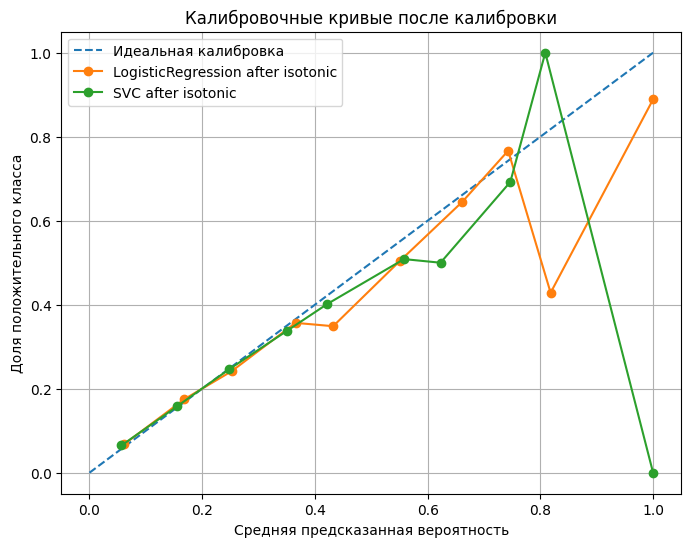

In [98]:
# Визуализация

prob_true_logreg_after_93, prob_pred_logreg_after_93 = calibration_curve(
    y_test,
    y_test_proba_logreg_after_93,
    n_bins=10,
    strategy="uniform"
)

prob_true_svc_after_93, prob_pred_svc_after_93 = calibration_curve(
    y_test,
    y_test_proba_svc_after_93,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Идеальная калибровка")
plt.plot(prob_pred_logreg_after_93, prob_true_logreg_after_93, marker="o", label="LogisticRegression after isotonic")
plt.plot(prob_pred_svc_after_93, prob_true_svc_after_93, marker="o", label="SVC after isotonic")

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Доля положительного класса")
plt.title("Калибровочные кривые после калибровки")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
# Таблицы точек

calibration_table_logreg_after_93 = pd.DataFrame({
    "predicted_probability": prob_pred_logreg_after_93,
    "true_fraction": prob_true_logreg_after_93
})

calibration_table_svc_after_93 = pd.DataFrame({
    "predicted_probability": prob_pred_svc_after_93,
    "true_fraction": prob_true_svc_after_93
})

print("LogisticRegression after isotonic calibration")
display(calibration_table_logreg_after_93)

print("SVC after isotonic calibration")
display(calibration_table_svc_after_93)

LogisticRegression after isotonic calibration


,predicted_probability,true_fraction
0,0.061034,0.067444
1,0.168140,0.174902
2,0.252458,0.241864
3,0.365689,0.356813
4,0.432328,0.348837
5,0.550077,0.503341
6,0.661786,0.645455
7,0.742857,0.766667
8,0.818182,0.428571
9,1.000000,0.888889


SVC after isotonic calibration


,predicted_probability,true_fraction
0,0.056839,0.064952
1,0.156081,0.158665
2,0.247772,0.246287
3,0.350109,0.337580
4,0.421912,0.401709
5,0.558136,0.508621
6,0.622885,0.500000
7,0.746675,0.692308
8,0.808732,1.000000
9,1.000000,0.000000


#### Вывод по пункту 9.3

После применения `isotonic calibration` качество вероятностных прогнозов обеих моделей существенно улучшилось.

Для `LogisticRegression`:

- `Brier score` уменьшился с `0.1990` до `0.1238`
- `ECE` уменьшился с `0.2587` до `0.0103`
- `MCE` изменился с `0.3778` до `0.3896`

Для `SVC`:

- `Brier score` уменьшился с `0.2012` до `0.1242`
- `ECE` уменьшился с `0.2635` до `0.0092`
- `MCE` изменился с `0.3814` до `1.0000`

Полученные результаты показывают, что после калибровки обе модели стали значительно лучше в среднем согласовывать предсказанные вероятности с фактической частотой положительного класса: это хорошо видно по заметному снижению `Brier score` и особенно `ECE`.

При этом `MCE` после калибровки не улучшился: для `LogisticRegression` он немного вырос, а для `SVC` вырос очень сильно. Это означает, что при общем улучшении калибровки в отдельных бинах всё ещё могут сохраняться локальные сильные отклонения, особенно у `SVC`.

Сравнение откалиброванных моделей показывает, что:

- по `Brier score` немного лучше выглядит **LogisticRegression** (`0.1238` против `0.1242`);
- по `ECE` немного лучше выглядит **SVC** (`0.0092` против `0.0103`);
- по `MCE` значительно стабильнее выглядит **LogisticRegression** (`0.3896` против `1.0000`).

Таким образом, после `isotonic calibration` обе модели дают гораздо более качественные вероятностные оценки, чем до калибровки, однако **LogisticRegression** остается более предпочтительной финальной моделью, поскольку сочетает лучший `Brier score`, сопоставимый `ECE` и значительно более устойчивое поведение по `MCE`, чем `SVC`.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Вывод по разделу 9

В данном разделе была исследована калибровка вероятностных прогнозов моделей `LogisticRegression` и `SVC`.

На этапе предварительного анализа было установлено, что до дополнительной настройки обе модели являются недостаточно хорошо откалиброванными: их calibration curves заметно отклонялись от линии идеальной калибровки, а предсказанные вероятности систематически переоценивали вероятность положительного класса.

Для исправления этого была выполнена `isotonic calibration` на отдельной калибровочной выборке, что соответствует корректной методике и исключает использование тестовой выборки при обучении калибратора.

После калибровки качество вероятностных прогнозов обеих моделей заметно улучшилось:

- существенно снизился `Brier score`;
- резко уменьшился `ECE`;
- calibration curves в среднем стали ближе к диагонали идеальной калибровки.

При этом `MCE` после калибровки не улучшился: у `LogisticRegression` он немного вырос, а у `SVC` вырос очень существенно. Это означает, что при общем улучшении калибровки в отдельных бинах по-прежнему могут сохраняться локальные сильные отклонения.

Итоговые результаты после калибровки:

- **LogisticRegression**:
  - `Brier score = 0.1238`
  - `ECE = 0.0103`
  - `MCE = 0.3896`

- **SVC**:
  - `Brier score = 0.1242`
  - `ECE = 0.0092`
  - `MCE = 1.0000`

Обе модели после `isotonic calibration` показали гораздо более качественные вероятностные оценки по средним метрикам, чем до калибровки. При этом `LogisticRegression` имеет немного лучший `Brier score`, сопоставимый `ECE` и значительно более устойчивое поведение по `MCE`, чем `SVC`.

С учетом результатов предыдущих разделов и итогов калибровки в качестве основной финальной модели целесообразно оставить **LogisticRegression с isotonic calibration**, поскольку она сочетает хорошее качество классификации и более надежные вероятностные прогнозы.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [100]:
# 10.1-10.2 (фактически уже посчитали в прошлом разделе)

before_10 = (
    calibration_metrics_93[calibration_metrics_93["state"] == "before calibration"]
    .set_index("model")[["Brier score", "ECE", "MCE"]]
    .rename(columns={
        "Brier score": "Brier before",
        "ECE": "ECE before",
        "MCE": "MCE before"
    })
)

after_10 = (
    calibration_metrics_93[calibration_metrics_93["state"] == "after isotonic calibration"]
    .set_index("model")[["Brier score", "ECE", "MCE"]]
    .rename(columns={
        "Brier score": "Brier after",
        "ECE": "ECE after",
        "MCE": "MCE after"
    })
)

comparison_10 = before_10.join(after_10)

comparison_10["Brier improvement"] = comparison_10["Brier before"] - comparison_10["Brier after"]
comparison_10["ECE improvement"] = comparison_10["ECE before"] - comparison_10["ECE after"]
comparison_10["MCE improvement"] = comparison_10["MCE before"] - comparison_10["MCE after"]

comparison_10 = comparison_10.reset_index().round(6)

display(comparison_10)

,model,Brier before,ECE before,MCE before,Brier after,ECE after,MCE after,Brier improvement,ECE improvement,MCE improvement
0,LogisticRegression,0.198965,0.258718,0.377848,0.123792,0.010267,0.38961,0.075173,0.248451,-0.011762
1,SVC,0.201248,0.263483,0.381371,0.124163,0.009173,1.00000,0.077086,0.254310,-0.618629


### Вывод по разделу 10

В данном разделе было проведено количественное сравнение качества калибровки моделей `LogisticRegression` и `SVC` до и после применения `isotonic calibration`.

Для оценки использовались метрики `Brier score`, `ECE` и `MCE`.

Результаты показали, что после калибровки у обеих моделей заметно улучшились средние метрики качества вероятностных прогнозов:

- снизился `Brier score`;
- существенно уменьшился `ECE`.

Для `LogisticRegression`:

- `Brier score` улучшился на `0.0752` (с `0.1990` до `0.1238`);
- `ECE` улучшился на `0.2485` (с `0.2587` до `0.0103`);
- `MCE` не улучшился и немного ухудшился: с `0.3778` до `0.3896`.

Для `SVC`:

- `Brier score` улучшился на `0.0771` (с `0.2012` до `0.1242`);
- `ECE` улучшился на `0.2543` (с `0.2635` до `0.0092`);
- `MCE` заметно ухудшился: с `0.3814` до `1.0000`.

Таким образом, `isotonic calibration` оказалась эффективной с точки зрения средних метрик калибровки (`Brier score` и `ECE`) для обеих моделей, однако по метрике `MCE` улучшения не произошло. Это означает, что в отдельных бинах после калибровки могут сохраняться или даже усиливаться локальные сильные отклонения между предсказанной вероятностью и фактической долей положительного класса.

С учетом результатов предыдущих этапов исследования, после калибровки более предпочтительной итоговой моделью остается **LogisticRegression с isotonic calibration**, поскольку она сочетает лучший `Brier score`, сопоставимый `ECE` и значительно более устойчивое поведение по `MCE`, чем `SVC`.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

In [101]:
# 11.1 Сводная таблица результатов

# Базовая модель DummyClassifier
dummy_summary_111 = (
    section6_results_df[section6_results_df["model"] == "DummyClassifier"]
    .copy()
    .reset_index(drop=True)
)

dummy_summary_111["stage"] = "baseline"
dummy_summary_111 = dummy_summary_111[[
    "stage", "model", "cv_pr_auc", "cv_precision", "cv_recall", "cv_f1"
]].round(6)

print("Базовая модель")
display(dummy_summary_111)


# Финальная модель LogisticRegression
final_model_summary_111 = pd.DataFrame([{
    "stage": "final model",
    "model": "LogisticRegression",
    "hyperparameters": "C=0.1, penalty=l2, class_weight=balanced",
    "PR-AUC": final_test_metrics.loc[0, "PR-AUC"],
    "Precision": final_test_metrics.loc[0, "Precision"],
    "Recall": final_test_metrics.loc[0, "Recall"],
    "F1-score": final_test_metrics.loc[0, "F1-score"],
    "ROC-AUC": final_test_metrics.loc[0, "ROC-AUC"]
}]).round(6)

print("Финальная модель")
display(final_model_summary_111)


# Метрики финальной модели до и после калибровки
final_calibration_summary_111 = (
    calibration_metrics_93[calibration_metrics_93["model"] == "LogisticRegression"]
    .copy()
    .reset_index(drop=True)
    .round(6)
)

print("Качество калибровки финальной модели")
display(final_calibration_summary_111)


# Топ-5 самых важных признаков
top5_features_111 = (
    coef_table_83[["feature", "coefficient", "abs_coefficient"]]
    .head(5)
    .copy()
    .reset_index(drop=True)
    .round(6)
)

top5_features_111.insert(0, "rank", range(1, len(top5_features_111) + 1))

print("Топ-5 самых важных признаков финальной модели")
display(top5_features_111)

Базовая модель


,stage,model,cv_pr_auc,cv_precision,cv_recall,cv_f1
0,baseline,DummyClassifier,0.172067,0.0,0.0,0.0


Финальная модель


,stage,model,hyperparameters,PR-AUC,Precision,Recall,F1-score,ROC-AUC
0,final model,LogisticRegression,"C=0.1, penalty=l2, class_weight=balanced",0.405435,0.316676,0.677513,0.431612,0.752754


Качество калибровки финальной модели


,model,state,Brier score,ECE,MCE
0,LogisticRegression,before calibration,0.198965,0.258718,0.377848
1,LogisticRegression,after isotonic calibration,0.123792,0.010267,0.389610


Топ-5 самых важных признаков финальной модели


,rank,feature,coefficient,abs_coefficient
0,1,target_enc__site_id,2.286261,2.286261
1,2,target_enc__app_id,2.136165,2.136165
2,3,target_enc__C17,1.541784,1.541784
3,4,target_enc__site_domain,1.167630,1.167630
4,5,target_enc__C14,0.914450,0.914450


### Вывод по пункту 11.2

По сравнению с базовой моделью качество существенно улучшилось.  
`DummyClassifier` показал `PR-AUC = 0.1721`, что соответствует наивному baseline для несбалансированной задачи, тогда как финальная модель `LogisticRegression` на тестовой выборке получила `PR-AUC = 0.4054` и `ROC-AUC = 0.7528`. Это означает, что модель действительно научилась заметно лучше отделять клики от некликов по сравнению с наивным подходом.

При стандартном пороге классификации финальная модель показывает `Precision = 0.3167`, `Recall = 0.6775` и `F1-score = 0.4316`. Это говорит о том, что модель находит значительную долю реальных кликов, хотя и допускает часть ложноположительных срабатываний, что в целом ожидаемо для несбалансированной задачи.

На вероятность клика сильнее всего влияют признаки, вошедшие в топ-5 по модулю коэффициентов логистической регрессии: `target_enc__site_id`, `target_enc__app_id`, `target_enc__C17`, `target_enc__site_domain` и `target_enc__C14`. Это показывает, что модель в первую очередь опирается на наиболее информативные признаки контекста показа объявления, площадки, приложения и параметров показа.

С точки зрения калибровки модель после дополнительной настройки показывает заметно более качественные вероятностные прогнозы.  
До калибровки у `LogisticRegression` метрики были следующими: `Brier score = 0.1990`, `ECE = 0.2587`, `MCE = 0.3778`. После применения `isotonic calibration` они изменились до `Brier score = 0.1238`, `ECE = 0.0103`, `MCE = 0.3896`. Это означает, что среднее качество вероятностных прогнозов существенно улучшилось, хотя в отдельных бинах по метрике `MCE` локальные отклонения полностью не исчезли.

Итоговую модель можно считать **хорошим финальным решением в рамках проекта**:  
она оформлена в виде воспроизводимого `Pipeline`, использует корректную предобработку, показывает качество заметно лучше baseline и после калибровки дает более надежные вероятностные оценки. Перед практическим использованием дополнительно стоит сохранить артефакты модели, настроить мониторинг качества и калибровки на новых данных, а также предусмотреть периодическое переобучение при изменении распределения трафика.

### 11.3 Рекомендации

Несмотря на то, что итоговая модель показывает хорошие результаты и после калибровки выдаёт качественные вероятностные прогнозы, у проекта остаётся несколько направлений для дальнейшего улучшения.

Во-первых, можно расширить пространство признаков.  
Сейчас модель в основном опирается на признаки контекста показа, площадки и приложения. Потенциально качество можно повысить за счёт более содержательных агрегированных признаков: частот появления категорий, статистик CTR по историческим группам, временных признаков более высокого уровня, а также дополнительных взаимодействий между признаками.

Во-вторых, можно дополнительно улучшить вероятностные оценки.  
Хотя `isotonic calibration` заметно повысила качество калибровки, полезно сравнить её с другими подходами, например `Platt scaling`, а также проверить устойчивость калибровки на других разбиениях данных.

Наконец, перед использованием модели в продакшене важно предусмотреть регулярный мониторинг.  
Нужно отслеживать не только метрики классификации, но и качество калибровки на новых данных, поскольку распределение рекламного трафика со временем может меняться. Также желательно организовать периодическое переобучение модели и контроль смещения распределений признаков.

Таким образом, текущую модель можно считать хорошим и интерпретируемым решением, однако дальнейшее развитие проекта связано с расширением признакового пространства, более полным подбором гиперпараметров, тестированием более сложных алгоритмов и организацией мониторинга в продакшене.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [102]:
# 12.1

# Финальная калиброванная модель
calibrated_model = calibrated_logreg_92

# Базовый pipeline, на котором строилась калибровка
base_pipeline_for_artifacts = final_logreg_pipeline

# Получаем информацию о выбранных признаках
# Достаточно небольшой части train, так как нужны только имена колонок
X_selected_121 = base_pipeline_for_artifacts[:-1].transform(X_train.iloc[:5].copy())

selected_features_info = {
    "n_selected_features": len(X_selected_121.columns),
    "selected_feature_names": list(X_selected_121.columns)
}

# Папка для артефактов внутри репозитория
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Пути к файлам
preprocessor_path = artifacts_dir / "preprocessor.joblib"
calibrated_model_path = artifacts_dir / "calibrated_model.joblib"
selected_features_path = artifacts_dir / "selected_features_info.joblib"

# Сохраняем артефакты
joblib.dump(base_pipeline_for_artifacts[:-1], preprocessor_path)
joblib.dump(calibrated_model, calibrated_model_path)
joblib.dump(selected_features_info, selected_features_path)

print("Артефакты сохранены:")
print(preprocessor_path)
print(calibrated_model_path)
print(selected_features_path)

Артефакты сохранены:
artifacts\preprocessor.joblib
artifacts\calibrated_model.joblib
artifacts\selected_features_info.joblib


In [103]:
# 12.2 Проверка загрузки артефактов и совпадения результатов

# Загружаем артефакты обратно
loaded_feature_pipeline = joblib.load(preprocessor_path)
loaded_calibrated_model = joblib.load(calibrated_model_path)
loaded_selected_features_info = joblib.load(selected_features_path)

print("Артефакты успешно загружены.")

# Новые данные для проверки
X_new_122 = X_test.iloc[:10].copy()

# Предсказания исходной модели
y_pred_original_122 = calibrated_model.predict(X_new_122)
y_proba_original_122 = calibrated_model.predict_proba(X_new_122)[:, 1]

# Предсказания загруженной модели
y_pred_loaded_122 = loaded_calibrated_model.predict(X_new_122)
y_proba_loaded_122 = loaded_calibrated_model.predict_proba(X_new_122)[:, 1]

# Проверка совпадения результатов
pred_match_122 = np.array_equal(y_pred_original_122, y_pred_loaded_122)
proba_match_122 = np.allclose(y_proba_original_122, y_proba_loaded_122)

artifact_check_122 = pd.DataFrame({
    "y_pred_original": y_pred_original_122,
    "y_pred_loaded": y_pred_loaded_122,
    "y_proba_original": y_proba_original_122,
    "y_proba_loaded": y_proba_loaded_122
}).round(6)

display(artifact_check_122)

print("Совпадают ли классы:", pred_match_122)
print("Совпадают ли вероятности:", proba_match_122)

# Дополнительная проверка pipeline подготовки признаков
X_new_transformed_122 = loaded_feature_pipeline.transform(X_new_122)

print("Размер данных после загрузки pipeline подготовки признаков:", X_new_transformed_122.shape)
print("Количество сохраненных выбранных признаков:", loaded_selected_features_info["n_selected_features"])

feature_count_match_122 = (
    X_new_transformed_122.shape[1] == loaded_selected_features_info["n_selected_features"]
)

feature_names_match_122 = (
    list(X_new_transformed_122.columns) == loaded_selected_features_info["selected_feature_names"]
)

print("Совпадает ли количество признаков:", feature_count_match_122)
print("Совпадают ли имена признаков:", feature_names_match_122)

print("Первые 10 выбранных признаков:")
print(loaded_selected_features_info["selected_feature_names"][:10])

Артефакты успешно загружены.


,y_pred_original,y_pred_loaded,y_proba_original,y_proba_loaded
0,0,0,0.454545,0.454545
1,0,0,0.193407,0.193407
2,0,0,0.080664,0.080664
3,0,0,0.272727,0.272727
4,0,0,0.352490,0.352490
5,0,0,0.037778,0.037778
6,0,0,0.065421,0.065421
7,0,0,0.352490,0.352490
8,0,0,0.080664,0.080664
9,1,1,0.589744,0.589744


Совпадают ли классы: True
Совпадают ли вероятности: True
Размер данных после загрузки pipeline подготовки признаков: (10, 40)
Количество сохраненных выбранных признаков: 40
Совпадает ли количество признаков: True
Совпадают ли имена признаков: True
Первые 10 выбранных признаков:
['num__ml_feature_5', 'num__ml_feature_6', 'num__ml_feature_8', 'num__ml_feature_9', 'num__ml_feature_10', 'ohe__site_category_28905ebd', 'ohe__site_category_3e814130', 'ohe__site_category_50e219e0', 'ohe__site_category_76b2941d', 'ohe__site_category_f028772b']


### Вывод по разделу 12

В рамках финального этапа были сохранены ключевые артефакты итогового решения: pipeline подготовки признаков, калиброванная модель и информация о выбранных признаках. Это позволяет использовать модель повторно без необходимости заново выполнять полный цикл предобработки, отбора признаков и обучения.

После сохранения была проведена проверка загрузки артефактов на новых данных. Результаты показали, что предсказанные классы и вероятности у исходной и загруженной модели совпадают, а pipeline подготовки признаков после загрузки формирует тот же набор признаков с теми же именами. Следовательно, итоговое решение корректно сохраняется, загружается и может считаться воспроизводимым.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Артефакты сохранены.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Андрей, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>